# STINTSY Major Course Output

This notebook presents the development of **three supervised machine learning models** using the *Organ Retrieval and Collection of Health Information for Donation (ORCHID)* dataset.

## Objective
The primary objective is to **predict the successful transplantation of a donor heart** (Binary: *Yes/No*) based on:
- Donor demographics  
- Cause of death  
- Clinical data, including:  
  - Arterial Blood Gas (ABG) events
  - Complete Blood Count (CBC) events
  - Chemistry events
  - Culture events
  - Fluid Balance events
  - Hemodynamics events
  - Serology events  

Predict **Y** (Successful Transplant) based on **X** (Donor Profiles and Clinical Markers).

## Dataset
The dataset used in this project is sourced from the ORCHID database. Detailed descriptions and download links are available below:

**Link:** https://physionet.org/content/orchid/2.1.1/

## Contents of this Notebook 
- Dataset Insights
    - Unique Values
- Data Cleaning
    - Cohort Selection
    - Data Cleaning
- Exploratory Data Analysis
    - Missing Data
    - Feature Distributions
    - Correlation Analysis
    - Target vs Feature Analysis
- Data Pre-processing  
    - Medical Relevance
    - Feature Engineering
- Model Selection, Training, Analysis, & Tuning
- Model Evaluation and Comparison  

## Setup Instructions
Dependencies and instructions for running this notebook are provided in the following section.

# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats 
import sklearn as sklearn
import torch.optim as optim
import torch.nn as nn
import torch

from sklearn.preprocessing import StandardScaler
%matplotlib inline

## Set Random Seeds for Reproducibility

Setting random seeds ensures that all stochastic processes (model initialization, neural network training, random transformations) produce identical results across runs. This is essential for scientific reproducibility and peer review.

In [47]:
import random

# Set random seeds for reproducibility
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Optional: Disable non-deterministic algorithms for full reproducibility
# torch.backends.cudnn.deterministic = True
# torch.backends.cudnn.benchmark = False

print(f"Random seeds set to {SEED} for reproducible results")

Random seeds set to 42 for reproducible results


# Dataset Insights

Before cleaning the data, it is essential to know the different contents of the dataset. The code below will show the different unique values in the multi-source dataset, in order to have a prior knowledge on the different features that will be relevant in completing our objective.

### OPOReferrals
This is the different donor demographics of the patients including the various outcomes of the organs in relation to transplants.

In [3]:
na_values = ["", " ", "na ", "na"]
dtype_dict = {7: str, 12: str}

OPOreferrals = pd.read_csv(
    'orchid-2.1.1/OPOReferrals.csv', 
    na_values=na_values, 
    dtype=dtype_dict,
    low_memory=False
)

cols_to_check = ['opo', 'gender', 'race', 'brain_death', 'cause_of_death_opo', 'cause_of_death_unos', 'mechanism_of_death', 
                 'circumstances_of_death', 'abo_blood_type', 'abo_rh', 'outcome_heart']

for col in cols_to_check:
    print(f"--- Unique values for {col} ---")
    print(f"Count: {OPOreferrals[col].nunique()}") 
    print(OPOreferrals[col].unique())
    
    null_count = OPOreferrals[col].isnull().sum()
    print(f"Missing Values (NaN): {null_count}")
    print("\n")

--- Unique values for opo ---
Count: 6
<StringArray>
['OPO1', 'OPO2', 'OPO3', 'OPO4', 'OPO5', 'OPO6']
Length: 6, dtype: str
Missing Values (NaN): 0


--- Unique values for gender ---
Count: 2
<StringArray>
['M', 'F', nan]
Length: 3, dtype: str
Missing Values (NaN): 61


--- Unique values for race ---
Count: 4
<StringArray>
['White / Caucasian', 'Black / African American', 'Hispanic',
 'Other / Unknown']
Length: 4, dtype: str
Missing Values (NaN): 0


--- Unique values for brain_death ---
Count: 2
[False  True]
Missing Values (NaN): 0


--- Unique values for cause_of_death_opo ---
Count: 80
<StringArray>
[                                               nan,
                         'Cardiac - Other, specify',
                                        'ICB / ICH',
                                           'Sepsis',
                                              'GSW',
                     'Respiratory - Other, specify',
                                        'Pneumonia',
                  

### ABGEvents
This is the different ABG related events done to a particular patient

In [4]:
na_values = ["", " ", '""' "na ", "na"]

ABGEvents = pd.read_csv(
    'orchid-2.1.1/ABGEvents.csv', 
    na_values=na_values, 
    low_memory=False
)

cols_to_check = ['abg_ventilator_mode', 'abg_name']

for col in cols_to_check:
    print(f"--- Unique values for {col} ---")
    print(f"Count: {ABGEvents[col].nunique()}") 
    print(ABGEvents[col].unique())
    
    null_count = ABGEvents[col].isnull().sum()
    print(f"Missing Values (NaN): {null_count}")
    print("\n")

--- Unique values for abg_ventilator_mode ---
Count: 398
<StringArray>
[           'SIMV',             'CMV',            'PRVC',             'A/C',
           'Other',      'Apnea Test',              'PC',            'CPAP',
            'APRV',              'NC',
 ...
           'APRV ',        'Ambu Bag',       'Pre apnea',     'post apnea ',
            'auto',    'A/C - Supine', 'Other (specify)',      'A/C-Supine',
     'A/C ? Prone',      'A/C-zProne']
Length: 399, dtype: str
Missing Values (NaN): 27722


--- Unique values for abg_name ---
Count: 11
<StringArray>
['PH', 'PCO2', 'PO2', 'HCO3', 'BE', 'O2SAT', 'FIO2', 'Rate', 'TV', 'PEEP',
 'PIP']
Length: 11, dtype: str
Missing Values (NaN): 0




### CBCEvents
This is the different CBC related events done to a particular patient

In [9]:
na_values = ["", " ", '""' "na ", "na"]

CBCEvents = pd.read_csv(
    'orchid-2.1.1/CBCEvents.csv', 
    na_values=na_values, 
    low_memory=False
)

cols_to_check = ['cbc_name']

for col in cols_to_check:
    print(f"--- Unique values for {col} ---")
    print(f"Count: {CBCEvents[col].nunique()}") 
    print(CBCEvents[col].unique())
    
    null_count = CBCEvents[col].isnull().sum()
    print(f"Missing Values (NaN): {null_count}")
    print("\n")

--- Unique values for cbc_name ---
Count: 10
<StringArray>
['WBC', 'RBC', 'Hgb', 'Hct', 'Ptl', 'Segs', 'Lymp', 'Mono', 'Eos', 'Band']
Length: 10, dtype: str
Missing Values (NaN): 0




### ChemistryEvents
This is the different chemistry related events done to a particular patient

In [10]:
na_values = ["", " ", '""' "na ", "na"]

ChemistryEvents = pd.read_csv(
    'orchid-2.1.1/ChemistryEvents.csv', 
    na_values=na_values, 
    low_memory=False
)

cols_to_check = ['chem_name']

for col in cols_to_check:
    print(f"--- Unique values for {col} ---")
    print(f"Count: {ChemistryEvents[col].nunique()}") 
    print(ChemistryEvents[col].unique())
    
    null_count = ChemistryEvents[col].isnull().sum()
    print(f"Missing Values (NaN): {null_count}")
    print("\n")

--- Unique values for chem_name ---
Count: 42
<StringArray>
[             'Sodium',                   'K',                  'CI',
                 'CO2',                 'BUN',          'Creatinine',
 'CreatinineClearance',             'Glucose',             'Calcium',
                  'PT',                 'PTT',                 'INR',
             'Lactate',         'Phosphorous',                  'Mg',
             'SGOTAST',             'SGPTALT',             'Albumin',
           'TotalBili',          'DirectBili',        'TotalProtein',
             'AlkPhos',             'Amylase',              'Lipase',
                'CKMB',           'TroponinI',                 'Cpk',
              'HgbA1C',           'LipaseULN',          'Fibrinogen',
      'IonizedCalcium',                 'BNP',                 'GGT',
             'TotalMB',                 'LDH',           'SerumOsmo',
        'IndirectBili',            'CpkIndex',           'TroponinT',
        'SerumBetaHCG',       

### CultureEvents
This is the different infection culture related events done to a particular patient

In [11]:
na_values = ["", " ", '""' "na ", "na"]

CultureEvents = pd.read_csv(
    'orchid-2.1.1/CultureEvents.csv', 
    na_values=na_values, 
    low_memory=False
)

cols_to_check = ['culture_source']

for col in cols_to_check:
    print(f"--- Unique values for {col} ---")
    print(f"Count: {CultureEvents[col].nunique()}") 
    print(CultureEvents[col].unique())
    
    null_count = CultureEvents[col].isnull().sum()
    print(f"Missing Values (NaN): {null_count}")
    print("\n")

--- Unique values for culture_source ---
Count: 12
<StringArray>
[         'Blood',         'Sputum',          'Urine',          'Other',
 'L Bronch Gm St', 'R Bronch Gm St',       'R Bronch',       'L Bronch',
   'Sputum Gm St',            'CSF',          'Wound',              nan,
           'Lung']
Length: 13, dtype: str
Missing Values (NaN): 71




### FluidBalanceEvents
This is the different fluid balance related events done to a particular patient

In [12]:
na_values = ["", " ", '""' "na ", "na"]

FluidBalanceEvents = pd.read_csv(
    'orchid-2.1.1/FluidBalanceEvents.csv', 
    na_values=na_values, 
    low_memory=False
)

cols_to_check = ['fluid_name']

for col in cols_to_check:
    print(f"--- Unique values for {col} ---")
    print(f"Count: {FluidBalanceEvents[col].nunique()}") 
    print(FluidBalanceEvents[col].unique())
    
    null_count = FluidBalanceEvents[col].isnull().sum()
    print(f"Missing Values (NaN): {null_count}")
    print("\n")

--- Unique values for fluid_name ---
Count: 6
<StringArray>
['Crystalloid', 'Colloid', 'BloodProduct', 'Urine', 'NonUrine', 'Total']
Length: 6, dtype: str
Missing Values (NaN): 0




### HemoEvents
This is the different hemo related events done to a particular patient

In [13]:
na_values = ["", " ", '""' "na ", "na"]

HemoEvents = pd.read_csv(
    'orchid-2.1.1/HemoEvents.csv', 
    na_values=na_values, 
    low_memory=False
)

cols_to_check = ['measurement_name']

for col in cols_to_check:
    print(f"--- Unique values for {col} ---")
    print(f"Count: {HemoEvents[col].nunique()}") 
    print(HemoEvents[col].unique())
    
    null_count = HemoEvents[col].isnull().sum()
    print(f"Missing Values (NaN): {null_count}")
    print("\n")

--- Unique values for measurement_name ---
Count: 5
<StringArray>
['HeartRate', 'BPSystolic', 'BPDiastolic', 'UrineOutput', 'Temperature']
Length: 5, dtype: str
Missing Values (NaN): 0




### SerologyEvents
This is the different serology related events done to a particular patient

In [14]:
na_values = ["", " ", '""' "na ", "na"]

SerologyEvents = pd.read_csv(
    'orchid-2.1.1/SerologyEvents.csv', 
    na_values=na_values, 
    low_memory=False
)

cols_to_check = ['serology_name', 'serology_name_Other']

for col in cols_to_check:
    print(f"--- Unique values for {col} ---")
    print(f"Count: {SerologyEvents[col].nunique()}") 
    print(SerologyEvents[col].unique())
    
    null_count = SerologyEvents[col].isnull().sum()
    print(f"Missing Values (NaN): {null_count}")
    print("\n")

--- Unique values for serology_name ---
Count: 78
<StringArray>
[                  'Anti-CMV',                   'Anti-HBc',
                   'Anti-HCV',              'Anti-HIV I/II',
             'Anti-HTLV I/II',                     'Chagas',
                 'Chagas NAT',                    'CMV IgM',
                       'EBNA',            'EBV (VCA) (IgG)',
            'EBV (VCA) (IgM)',                  'HBcAB IgM',
                      'HBsAb',                      'HBsAg',
                    'HBV NAT',                    'HCV NAT',
            'HIV Ag/Ab Combo',                    'HIV NAT',
                   'HTLV NAT',                      'MHATP',
                     'Other1',              'Strongyloides',
                   'Syphilis',                'Toxo Ab IgG',
                        'WNV',                    'WNV NAT',
            'Hepatitis BC Ab',            'Hepatitis Bs Ag',
             'Hepatitis C Ab',          'HIV 1/2 plus O Ab',
   'HIV-1/HCV/HBV NAT

With the available datasets capturing various biological events, we can now identify which variables are most relevant to our primary objective.

In predicting the successful transplantation of a donor heart, organ viability is the key factor of interest. Each dataset (CSV file) contains clinical measurements and events that may influence this outcome. The relevant biological features extracted from these datasets are outlined below:



# 2. Data Cleaning

### 2.1 Cohort Selection
Given that this is a 100k+ rows of a dataset, we must only consider the patients that had a *outcome_heart* in the first place in order to be able to pin down what leads to a successful transplant. Counting the amount of rows that will lead to various outcomes shown below with its total count.

In [5]:
df_heart = OPOreferrals[OPOreferrals['outcome_heart'].notna()].copy()

print("--- Exact Counts for Heart Outcomes ---")
print(df_heart['outcome_heart'].value_counts())
print("\n--- Percentage Breakdown (%) ---")
print((df_heart['outcome_heart'].value_counts(normalize=True) * 100).round(2))
print(f"\nFinal Cohort Size (N): {len(df_heart)}")

--- Exact Counts for Heart Outcomes ---
outcome_heart
Transplanted                                     2987
Recovered for Research                            682
Recovered for Transplant but not Transplanted      21
Name: count, dtype: int64

--- Percentage Breakdown (%) ---
outcome_heart
Transplanted                                     80.95
Recovered for Research                           18.48
Recovered for Transplant but not Transplanted     0.57
Name: proportion, dtype: float64

Final Cohort Size (N): 3690


To formulate the heart transplant viability problem as a supervised machine learning task, the categorical **outcome_heart** column must be mapped to a binary target variable **Y** **(1/0)**.

#### Transplanted
- 1 (Success)
- The heart met all clinical criteria and was successfully utilized for transplant.
#### Recovered for Research
- 0 (Failure)
- The heart was ineligible for human transplantation due to clinical or physiological factors.
#### Recovered for Transplant but not Transplanted
- 0 (Failure)
- The heart was initially considered but ultimately rejected during the procurement process.

### 2.2 Data Cleaning

First, we need to check then clean  among the different events are medically relevant to the successfulness of a heart transplant. 

In [6]:
df_heart_cleaned = df_heart.copy()

columns_to_clean = ['opo', 'gender', 'race', 'brain_death', 'cause_of_death_opo', 'cause_of_death_unos', 
                    'mechanism_of_death', 'circumstances_of_death', 'abo_blood_type', 'abo_rh', 'outcome_heart']

columns_to_clean = [col for col in columns_to_clean if col in df_heart_cleaned.columns]

for col in columns_to_clean:
    df_heart_cleaned[col] = df_heart_cleaned[col].astype(str).str.lower().str.strip()

numeric_cols = ['age', 'height_in', 'weight_kg']
for col in numeric_cols:
    if col in df_heart_cleaned.columns:
        df_heart_cleaned[col] = pd.to_numeric(df_heart_cleaned[col], errors='coerce')

print(f"Final Heart Cohort Size: {len(df_heart_cleaned)}")
print(f"Unique OPOs: {df_heart_cleaned['opo'].unique()}")
print(f"Unique Genders: {df_heart_cleaned['gender'].unique()}")
print(f"Unique Race Categories: {df_heart_cleaned['race'].unique()}")
print(f"Unique Brain Death: {df_heart_cleaned['brain_death'].unique()}")
print(f"Unique Causes of Death (OPO): {df_heart_cleaned['cause_of_death_opo'].unique()}")
print(f"Unique Causes of Death (UNOS): {df_heart_cleaned['cause_of_death_unos'].unique()}")
print(f"Unique Mechanisms of Death: {df_heart_cleaned['mechanism_of_death'].unique()}")
print(f"Unique Circumstances of Death: {df_heart_cleaned['circumstances_of_death'].unique()}")
print(f"Unique Blood Types: {df_heart_cleaned['abo_blood_type'].unique()}")
print(f"Unique Rh Factors: {df_heart_cleaned['abo_rh'].unique()}")
print(f"Unique Outcomes: {df_heart_cleaned['outcome_heart'].unique()}")

Final Heart Cohort Size: 3690
Unique OPOs: <StringArray>
['opo1', 'opo2', 'opo3', 'opo4', 'opo5', 'opo6']
Length: 6, dtype: str
Unique Genders: <StringArray>
['m', 'f']
Length: 2, dtype: str
Unique Race Categories: <StringArray>
['hispanic', 'black / african american', 'white / caucasian',
 'other / unknown']
Length: 4, dtype: str
Unique Brain Death: <StringArray>
['true', 'false']
Length: 2, dtype: str
Unique Causes of Death (OPO): <StringArray>
[                                               nan,
                                              'gsw',
                   'infectious disease - bacterial',
                                         'drowning',
                                         'overdose',
                                   'other, specify',
                                        'icb / ich',
                                              'sah',
                                           'trauma',
                     'respiratory - other, specify',
                   

In [7]:
abg_events_cleaned = ABGEvents[ABGEvents['patient_id'].isin(df_heart_cleaned['patient_id'])].copy()
columns_to_clean = ['abg_ventilator_mode', 'abg_name']
for col in columns_to_clean:
    abg_events_cleaned[col] = abg_events_cleaned[col].astype(str).str.lower().str.strip()            

abg_events_cleaned['value'] = pd.to_numeric(abg_events_cleaned['value'], errors='coerce')

print(f"Rows in cleaned ABG: {len(abg_events_cleaned)}")
print(f"Unique Names: {abg_events_cleaned['abg_name'].unique()}")
print(f"Unique Ventilator Modes: {abg_events_cleaned['abg_ventilator_mode'].unique()}")

Rows in cleaned ABG: 566859
Unique Names: <StringArray>
['ph', 'pco2', 'po2', 'hco3', 'be', 'o2sat', 'fio2', 'rate', 'tv', 'peep',
 'pip']
Length: 11, dtype: str
Unique Ventilator Modes: <StringArray>
[           'simv',           'other',             'a/c',            'prvc',
            'aprv',              'pc',              'nc',      'apnea test',
             'cmv',            'cpap',            'hfov',           'bipap',
             'spv',          'apvcmv',           'apnea',             'pcv',
          'pcv-vg',             'vcv',           'ac-pc',         't piece',
         't-piece',          'bagged',              'vc',         'apv cmv',
             'vc+',         'bilevel',             'psv',         'unknown',
        'prvc a/c',        '8l nc o2',             'bvm',           'ac/vc',
         'vc-simv',             'imv',      'oscillator',             'apv',
          'ps 5/5',           'pcvvg',           'vc-ac',           'ac-vc',
         'apv/cmv',        'r

In [15]:
cbc_events_cleaned = CBCEvents[CBCEvents['patient_id'].isin(df_heart_cleaned['patient_id'])].copy()
columns_to_clean = ['cbc_name']
for col in columns_to_clean:
    cbc_events_cleaned[col] = cbc_events_cleaned[col].astype(str).str.lower().str.strip()

cbc_events_cleaned['value'] = pd.to_numeric(cbc_events_cleaned['value'], errors='coerce')

print(f"Rows in cleaned CBC: {len(cbc_events_cleaned)}")
print(f"Unique Names: {cbc_events_cleaned['cbc_name'].unique()}")

Rows in cleaned CBC: 223213
Unique Names: <StringArray>
['rbc', 'wbc', 'hgb', 'hct', 'ptl', 'segs', 'lymp', 'mono', 'eos', 'band']
Length: 10, dtype: str


In [16]:
chem_events_cleaned = ChemistryEvents[ChemistryEvents['patient_id'].isin(df_heart_cleaned['patient_id'])].copy()
columns_to_clean = ['chem_name', 'value_modifier']
for col in columns_to_clean:
    chem_events_cleaned[col] = chem_events_cleaned[col].astype(str).str.lower().str.strip()

chem_events_cleaned['value'] = pd.to_numeric(chem_events_cleaned['value'], errors='coerce')

print(f"Rows in cleaned Chemistry: {len(chem_events_cleaned)}")
print(f"Unique Names: {chem_events_cleaned['chem_name'].unique()}")
print(f"Unique Value Modifiers: {chem_events_cleaned['value_modifier'].unique()}")

Rows in cleaned Chemistry: 767374
Unique Names: <StringArray>
[             'sodium',                   'k',                  'ci',
                 'co2',                 'bun',          'creatinine',
 'creatinineclearance',             'glucose',             'calcium',
           'totalbili',             'sgotast',             'sgptalt',
             'albumin',        'totalprotein',             'alkphos',
                  'pt',                 'ptt',                 'inr',
         'phosphorous',                  'mg',                 'ggt',
                 'ldh',             'amylase',              'lipase',
           'lipaseuln',              'hgba1c',      'ionizedcalcium',
          'directbili',             'lactate',           'serumosmo',
           'troponini',                 'cpk',        'indirectbili',
                'ckmb',            'cpkindex',          'fibrinogen',
                 'bnp',           'troponint',        'serumbetahcg',
             'totalmb',     

In [17]:
culture_events_cleaned = CultureEvents[CultureEvents['patient_id'].isin(df_heart_cleaned['patient_id'])].copy()

columns_to_clean = ['culture_source', 'result']

for col in columns_to_clean:
    culture_events_cleaned[col] = culture_events_cleaned[col].astype(str).str.lower().str.strip()

print(f"Rows in cleaned Culture: {len(culture_events_cleaned)}")
print(f"Unique Sources: {culture_events_cleaned['culture_source'].unique()}")
print(f"Unique Results: {culture_events_cleaned['result'].unique()}")

Rows in cleaned Culture: 18037
Unique Sources: <StringArray>
[         'blood',          'urine', 'l bronch gm st', 'r bronch gm st',
       'r bronch',       'l bronch',   'sputum gm st',         'sputum',
          'other',            'csf',          'wound',              nan,
           'lung']
Length: 13, dtype: str
Unique Results: <StringArray>
['n', 'p', 'i']
Length: 3, dtype: str


In [18]:
fluid_balance_cleaned = FluidBalanceEvents[FluidBalanceEvents['patient_id'].isin(df_heart_cleaned['patient_id'])].copy()
columns_to_clean = ['fluid_name', 'fluid_type']
for col in columns_to_clean:
    fluid_balance_cleaned[col] = fluid_balance_cleaned[col].astype(str).str.lower().str.strip()

fluid_balance_cleaned['amount'] = pd.to_numeric(fluid_balance_cleaned['amount'], errors='coerce')

print(f"Rows in cleaned Fluid Balance: {len(fluid_balance_cleaned)}")
print(f"Unique Names: {fluid_balance_cleaned['fluid_name'].unique()}")
print(f"Unique Types: {fluid_balance_cleaned['fluid_type'].unique()}")

Rows in cleaned Fluid Balance: 30857
Unique Names: <StringArray>
['crystalloid', 'colloid', 'bloodproduct', 'urine', 'nonurine', 'total']
Length: 6, dtype: str
Unique Types: <StringArray>
['intake', 'output']
Length: 2, dtype: str


In [19]:
hemo_events_cleaned = HemoEvents[HemoEvents['patient_id'].isin(df_heart_cleaned['patient_id'])].copy()
columns_to_clean = ['measurement_name', 'measurement_type']
for col in columns_to_clean:
    hemo_events_cleaned[col] = hemo_events_cleaned[col].astype(str).str.lower().str.strip()

hemo_events_cleaned['value'] = pd.to_numeric(hemo_events_cleaned['value'], errors='coerce')

print(f"Rows in cleaned Hemodynamic Events: {len(hemo_events_cleaned)}")
print(f"Unique Names: {hemo_events_cleaned['measurement_name'].unique()}")
print(f"Unique Types: {hemo_events_cleaned['measurement_type'].unique()}")

Rows in cleaned Hemodynamic Events: 608160
Unique Names: <StringArray>
['heartrate', 'temperature', 'urineoutput', 'bpsystolic', 'bpdiastolic']
Length: 5, dtype: str
Unique Types: <StringArray>
['low', 'high', 'average', 'total']
Length: 4, dtype: str


In [20]:
serology_events_cleaned = SerologyEvents[SerologyEvents['patient_id'].isin(df_heart_cleaned['patient_id'])].copy()
columns_to_clean = ['serology_name', 'serology_name_Other', 'result']
for col in columns_to_clean: 
    serology_events_cleaned[col] = serology_events_cleaned[col].astype(str).str.lower().str.strip()

print(f"Rows in cleaned Serology: {len(serology_events_cleaned)}")
print(f"Unique Names: {serology_events_cleaned['serology_name'].unique()}")
print(f"Unique Results: {serology_events_cleaned['result'].unique()}")

Rows in cleaned Serology: 88533
Unique Names: <StringArray>
[                  'anti-cmv',                 'anti-hbcab',
                   'anti-hcv',              'anti-hiv i/ii',
             'anti-htlv i/ii',                     'chagas',
                 'chagas nat',                    'cmv igm',
                       'ebna',            'ebv (vca) (igg)',
            'ebv (vca) (igm)',                  'hbcab igm',
                      'hbsab',                      'hbsag',
                    'hbv nat',                    'hcv nat',
      'hiv ag/ab combo assay',                    'hiv nat',
                   'htlv nat',                      'mhatp',
                   'syphilis',                'toxo ab igg',
                        'wnv',                    'wnv nat',
                   'anti-hbc',            'hiv ag/ab combo',
              'strongyloides',                     'other1',
                    'nat hbv',                    'nat hcv',
                    'nat 

# 3. Exploratory Data Analysis

### 3.1 Missing Data

Given that we already have our 3690 patients with a heart outcome, it is time to check which of these patients actually have a record for the various events that was possibly administered that will be medically relevant in determining the success of a heart transplant.

In [40]:
cohort_ids = set(df_heart_cleaned['patient_id'])

def check_coverage(cleaned_df):
    table_ids = set(cleaned_df['patient_id'])
    overlap = cohort_ids.intersection(table_ids)
    count = len(overlap)
    pct = (count / len(cohort_ids)) * 100
    return count, pct

abg_count, abg_pct = check_coverage(abg_events_cleaned)
cbc_count, cbc_pct = check_coverage(cbc_events_cleaned)
chem_count, chem_pct = check_coverage(chem_events_cleaned)
culture_count, culture_pct = check_coverage(culture_events_cleaned)
fluid_count, fluid_pct = check_coverage(fluid_balance_cleaned)
hemo_count, hemo_pct = check_coverage(hemo_events_cleaned)
serology_count, serology_pct = check_coverage(serology_events_cleaned)

print(f"--- Coverage for Cleaned Cohort (N={len(cohort_ids)}) ---")
print(f"ABG Events:             {abg_count} patients ({abg_pct:.2f}%)")
print(f"CBC Events:             {cbc_count} patients ({cbc_pct:.2f}%)")
print(f"Chemistry Events:       {chem_count} patients ({chem_pct:.2f}%)")
print(f"Culture Events:         {culture_count} patients ({culture_pct:.2f}%)")
print(f"Fluid Balance Events:   {fluid_count} patients ({fluid_pct:.2f}%)")
print(f"Hemo Events:            {hemo_count} patients ({hemo_pct:.2f}%)")
print(f"Serology Events:        {serology_count} patients ({serology_pct:.2f}%)")

--- Coverage for Cleaned Cohort (N=3690) ---
ABG Events:             3685 patients (99.86%)
CBC Events:             3685 patients (99.86%)
Chemistry Events:       3685 patients (99.86%)
Culture Events:         3035 patients (82.25%)
Fluid Balance Events:   2762 patients (74.85%)
Hemo Events:            2769 patients (75.04%)
Serology Events:        3689 patients (99.97%)


Next is a heatmap to check how much of the demographics have missing data.

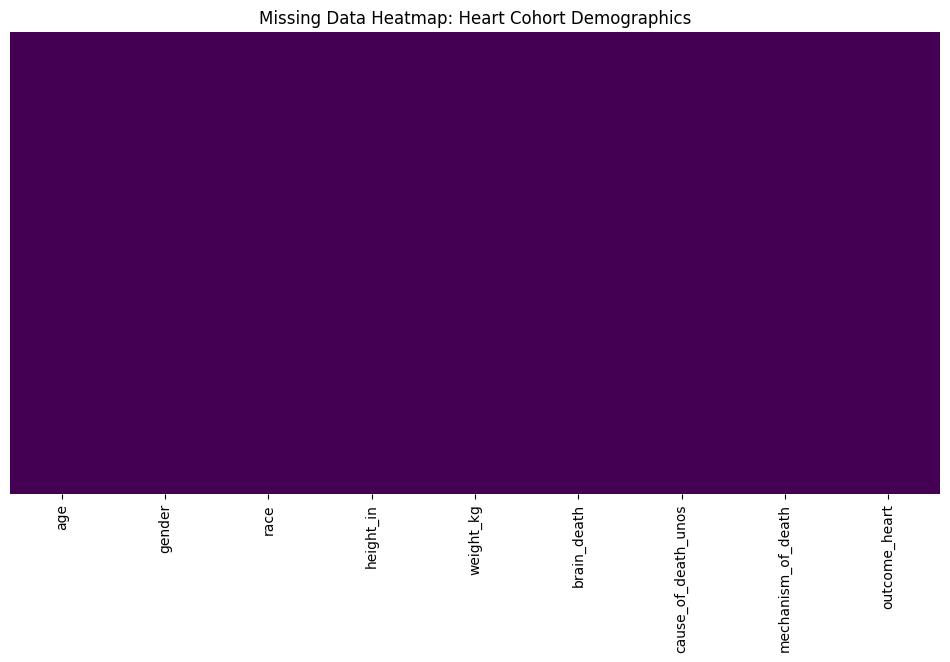

--- Missing Data Percentage per Column ---
height_in              0.11%
cause_of_death_unos    0.08%
mechanism_of_death     0.05%
age                     0.0%
gender                  0.0%
race                    0.0%
weight_kg               0.0%
brain_death             0.0%
outcome_heart           0.0%
dtype: str


In [41]:
heatmap_cols = ['age', 'gender', 'race', 'height_in', 'weight_kg', 'brain_death', 
              'cause_of_death_unos', 'mechanism_of_death', 'outcome_heart']

plt.figure(figsize=(12, 6))
sns.heatmap(df_heart_cleaned[heatmap_cols].isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap: Heart Cohort Demographics')
plt.show()

missing_stats = df_heart_cleaned[heatmap_cols].isnull().mean() * 100
missing_stats = missing_stats.sort_values(ascending=False)

print("--- Missing Data Percentage per Column ---")
print(missing_stats.round(2).map(lambda n: f'{n}%'))

To get a better idea of the most frequent events per patient, percentages of the Top 10 Most Common Features with at least one record will be gathered.

In [42]:
event_tables = {
    "ABG": (abg_events_cleaned, "abg_name"),
    "CBC": (cbc_events_cleaned, "cbc_name"),
    "Chemistry": (chem_events_cleaned, "chem_name"),
    "Culture": (culture_events_cleaned, "culture_source"),
    "Fluid Balance": (fluid_balance_cleaned, "fluid_name"),
    "Hemo": (hemo_events_cleaned, "measurement_name"),
    "Serology": (serology_events_cleaned, "serology_name")
}
print(f"--- Top 10 Most Common Features (N={len(df_heart_cleaned)}) ---\n")

for label, (df, col_name) in event_tables.items():
    if col_name in df.columns:
        top_10 = (
            df.groupby(col_name)['patient_id']
            .nunique()
            .sort_values(ascending=False)
            .head(10)
        )
        
        pct = (top_10 / len(df_heart_cleaned)) * 100
        
        print(f"[{label}] Top 10 Features:")
        for name, value in pct.items():
            print(f"  - {name:.<25} {value:>6.2f}%")
        print("-" * 40)
    else:
        print(f"Skipping {label}: Column '{col_name}' not found in DataFrame.")
        print("-" * 40)

--- Top 10 Most Common Features (N=3690) ---

[ABG] Top 10 Features:
  - be.......................  99.86%
  - pco2.....................  99.86%
  - ph.......................  99.86%
  - po2......................  99.86%
  - fio2.....................  99.84%
  - hco3.....................  99.84%
  - o2sat....................  99.78%
  - peep.....................  99.78%
  - rate.....................  99.76%
  - tv.......................  99.65%
----------------------------------------
[CBC] Top 10 Features:
  - wbc......................  99.86%
  - hct......................  75.07%
  - hgb......................  75.07%
  - ptl......................  75.07%
  - rbc......................  75.07%
  - lymp.....................  59.24%
  - mono.....................  59.24%
  - eos......................  57.67%
  - segs.....................  52.11%
  - band.....................  30.03%
----------------------------------------
[Chemistry] Top 10 Features:
  - sodium...................  99.86%

### 3.2 Feature Distributions

Histograms are used for the age, height, and weight to see the spread and outliers in the data. Meanwhile, a bar chart visualize the frequency of the gender, race, and other categories. These would show the imbalances or skews in the data.

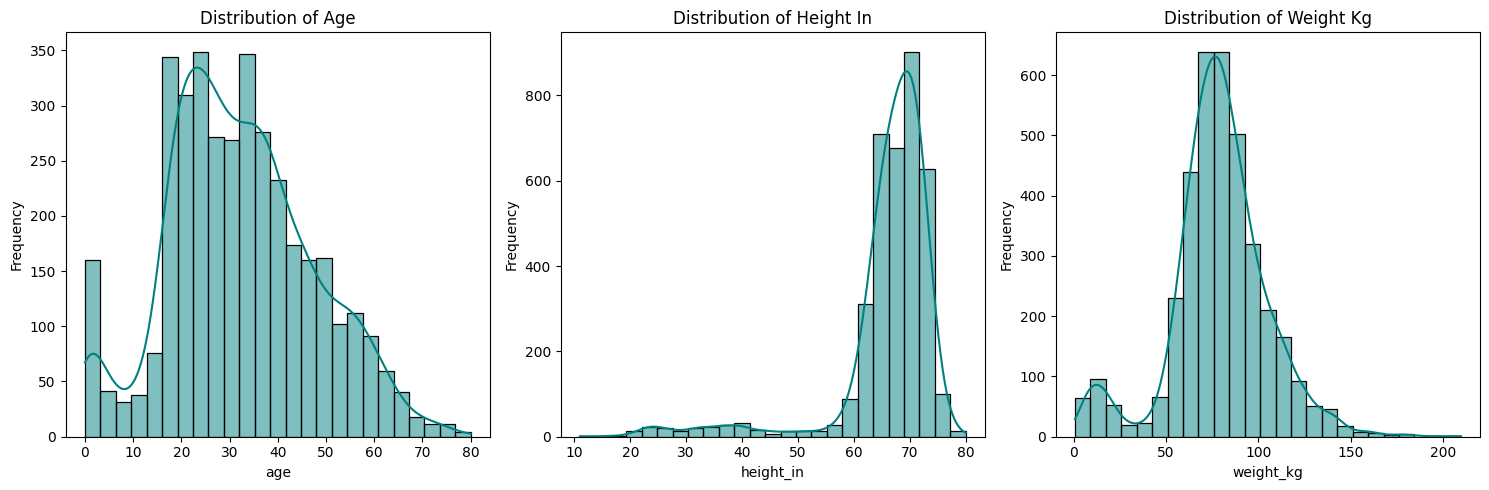

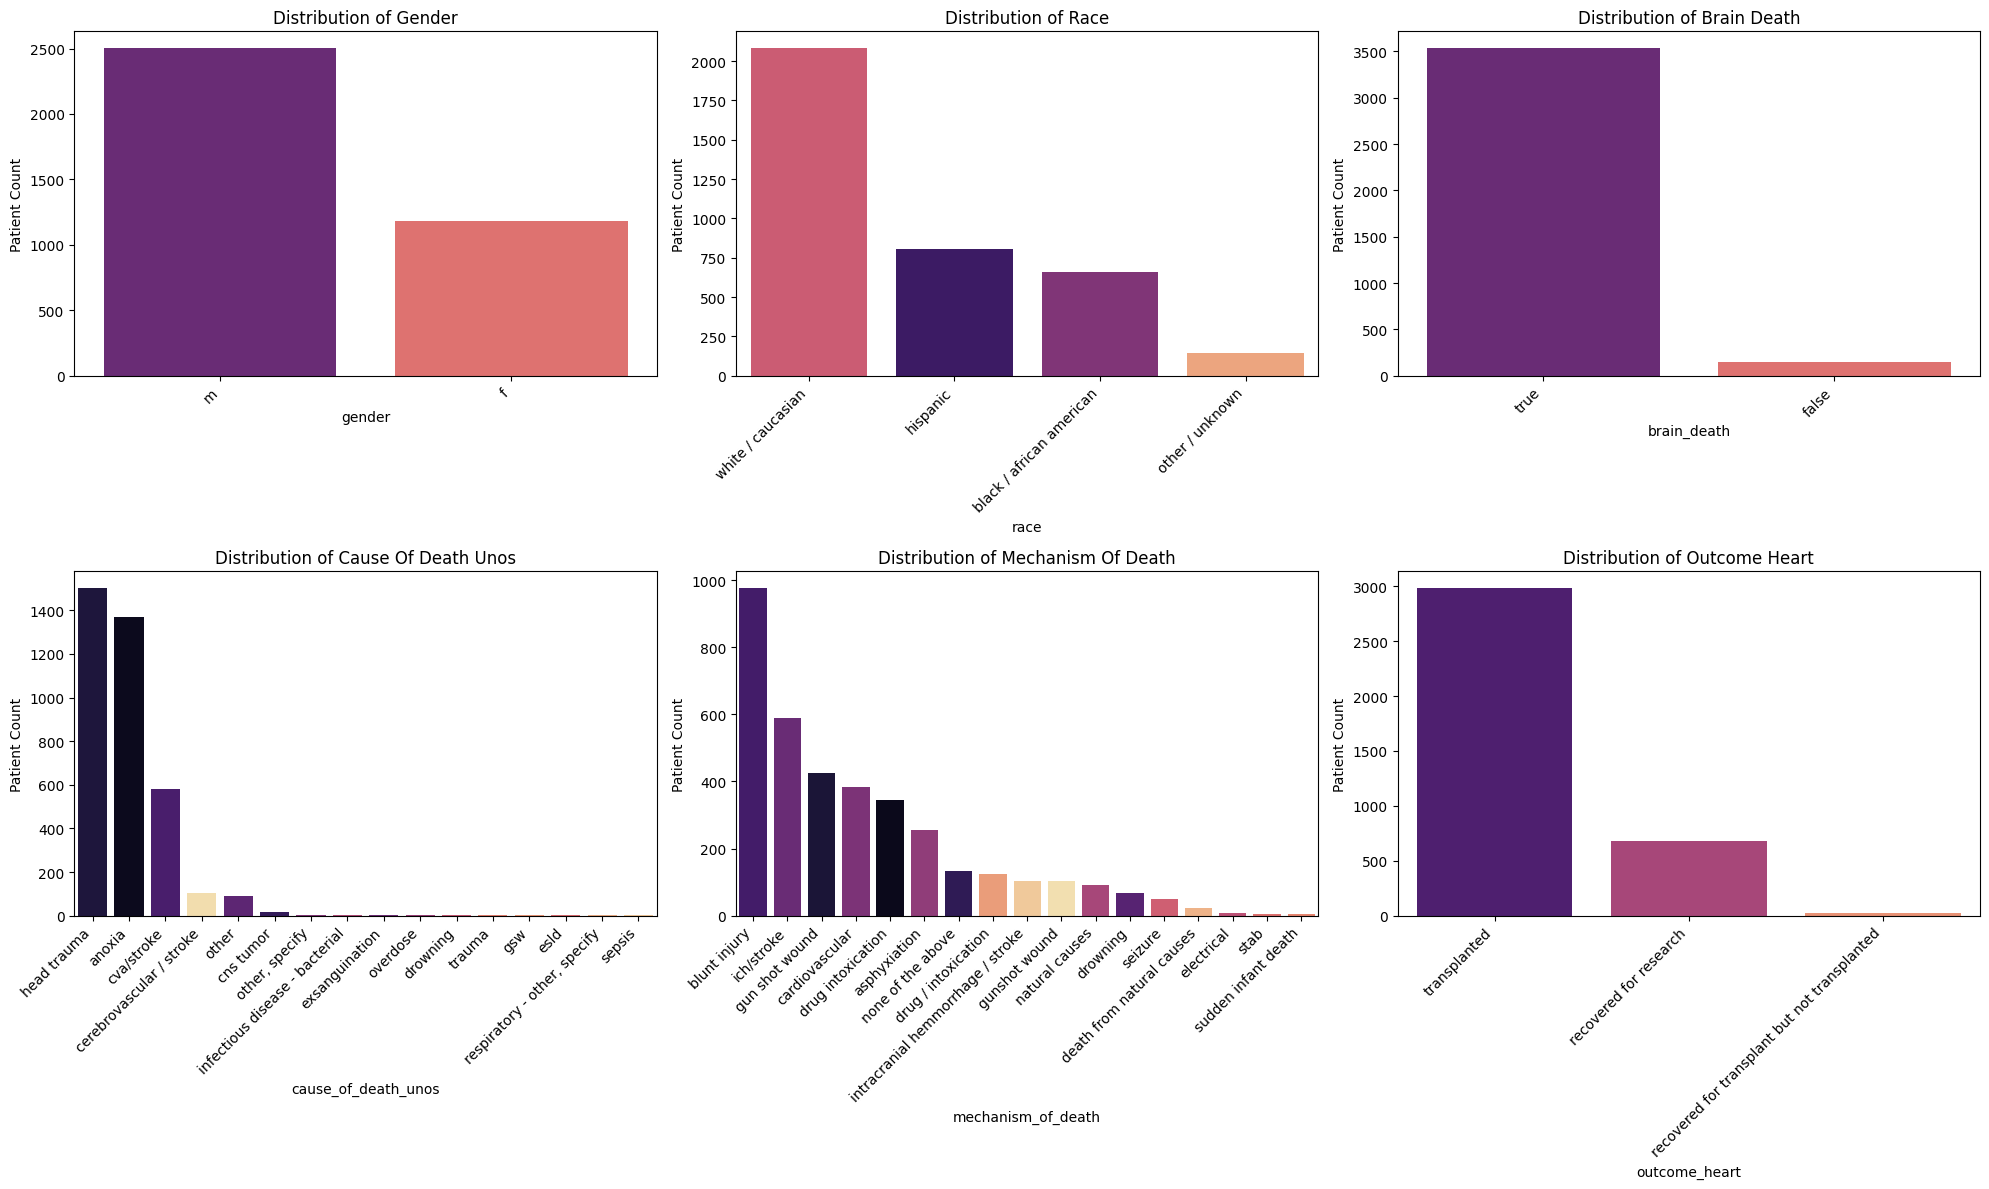

--- Categorical Frequency Breakdown ---

GENDER:
gender
m    67.9%
f    32.1%
Name: proportion, dtype: str

RACE:
race
white / caucasian           56.5%
hispanic                    21.8%
black / african american    17.8%
other / unknown              3.9%
Name: proportion, dtype: str

BRAIN_DEATH:
brain_death
true     95.9%
false     4.1%
Name: proportion, dtype: str

CAUSE_OF_DEATH_UNOS:
cause_of_death_unos
head trauma                       40.8%
anoxia                            37.1%
cva/stroke                        15.8%
cerebrovascular / stroke           2.8%
other                              2.4%
cns tumor                          0.5%
other, specify                     0.1%
infectious disease - bacterial     0.1%
exsanguination                     0.1%
overdose                           0.1%
drowning                           0.1%
trauma                             0.1%
gsw                                0.1%
esld                               0.0%
respiratory - other, specify 

In [43]:
numerical_demographics = ['age', 'height_in', 'weight_kg']
categorical_demographics = ['gender', 'race', 'brain_death', 'cause_of_death_unos', 'mechanism_of_death', 'outcome_heart']

plt.figure(figsize=(15, 5))
for i, col in enumerate(numerical_demographics):
    plt.subplot(1, 3, i+1)
    sns.histplot(df_heart_cleaned[col], kde=True, color='teal', bins=25)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('numeric_demographics.png')
plt.show()


plt.figure(figsize=(20, 12))
for i, col in enumerate(categorical_demographics):
    plt.subplot(2, 3, i+1)
    order = df_heart_cleaned[col].value_counts().index
    sns.countplot(data=df_heart_cleaned, x=col, order=order, palette='magma', hue=col, legend=False)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel('Patient Count')

plt.tight_layout()
plt.savefig('categorical_demographics.png')
plt.show()

print("--- Categorical Frequency Breakdown ---")
for col in categorical_demographics:
    print(f"\n{col.upper()}:")
    print(df_heart_cleaned[col].value_counts(normalize=True).map(lambda n: f'{n:.1%}'))

### 3.3 Correlation Analysis

Next is to gain an understanding on how much correlation is there with their demographics, primarily the age, height, and weight of the patients.

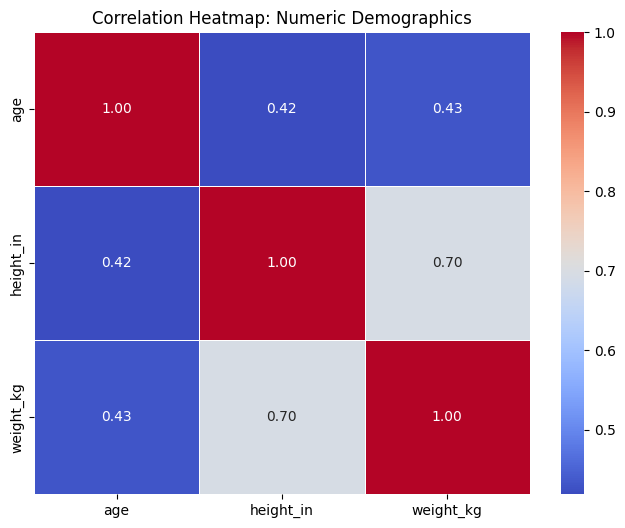

In [44]:
corr_matrix = df_heart_cleaned[['age', 'height_in', 'weight_kg']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Numeric Demographics')
plt.show()

### 3.4 Target vs Feature Analysis

Target vs Feature analysis identifies which variables actually differ between *"Transplanted"* and *"Research"* outcomes to reveal the main indicators in the data.

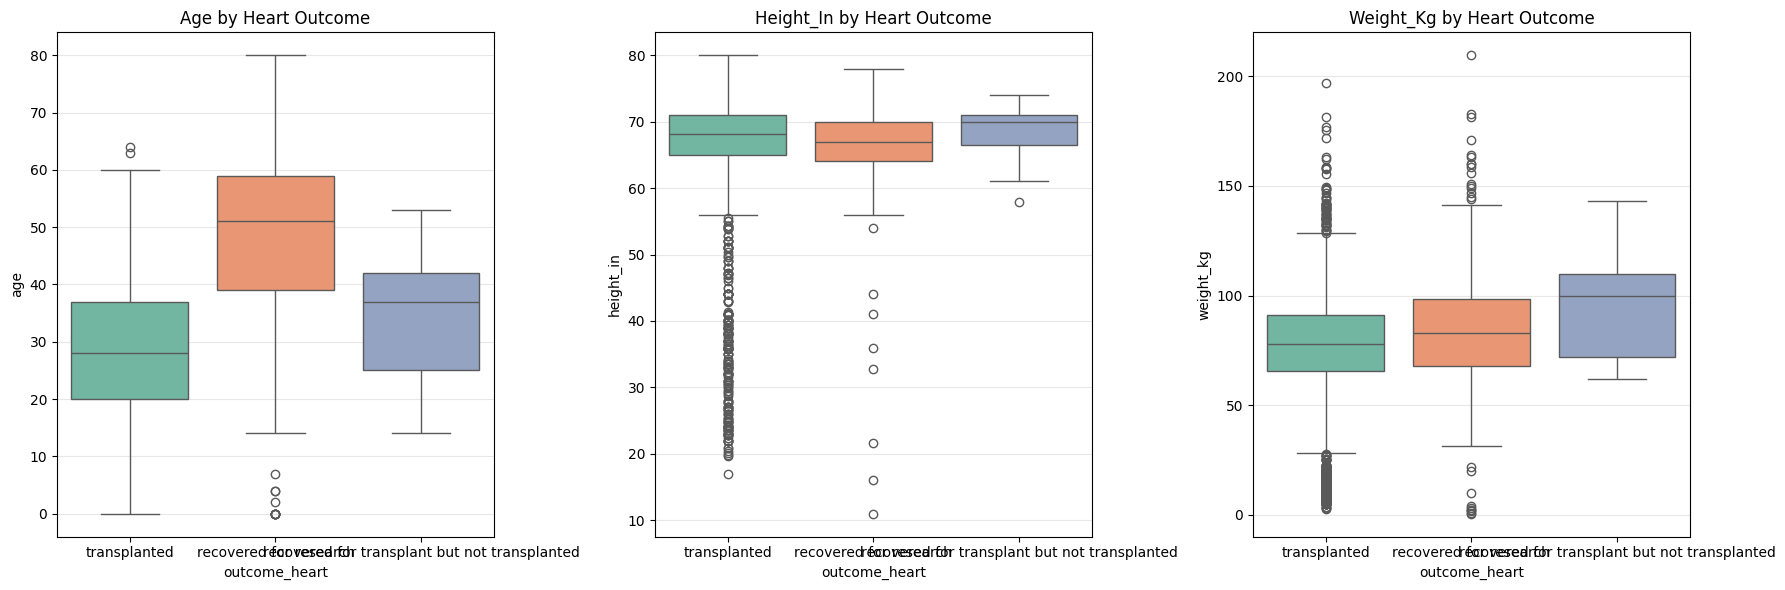

In [45]:
numerical_demographics = ['age', 'height_in', 'weight_kg']

plt.figure(figsize=(18, 6))

for i, col in enumerate(numerical_demographics):
    plt.subplot(1, 3, i+1)
    sns.boxplot(data=df_heart_cleaned, x='outcome_heart', y=col, palette='Set2', hue='outcome_heart', legend=False)
    plt.title(f'{col.title()} by Heart Outcome')
    plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

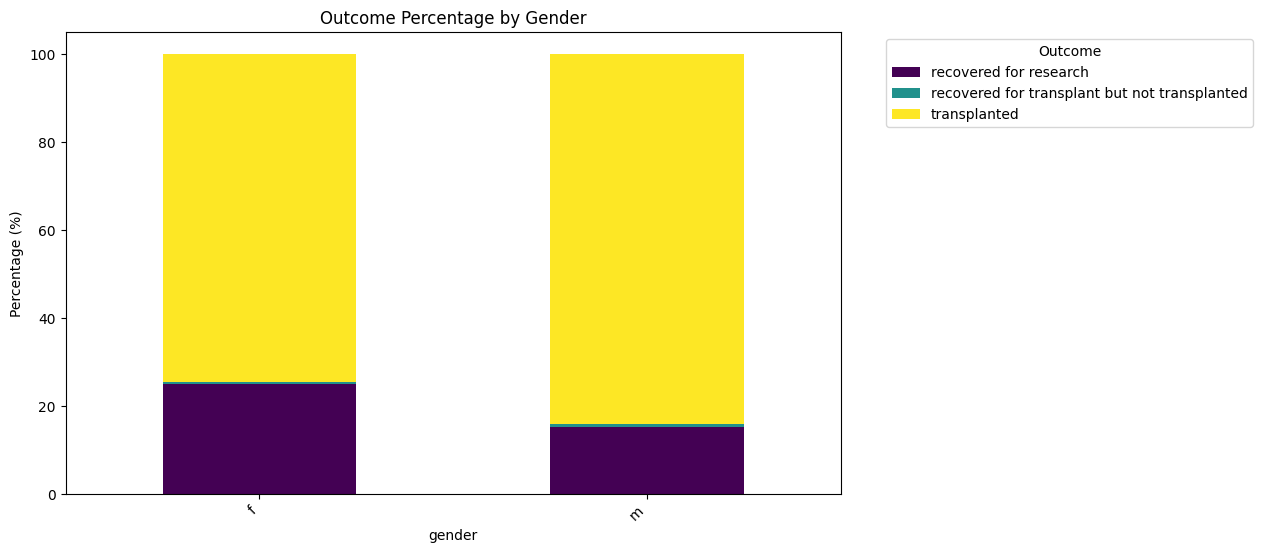

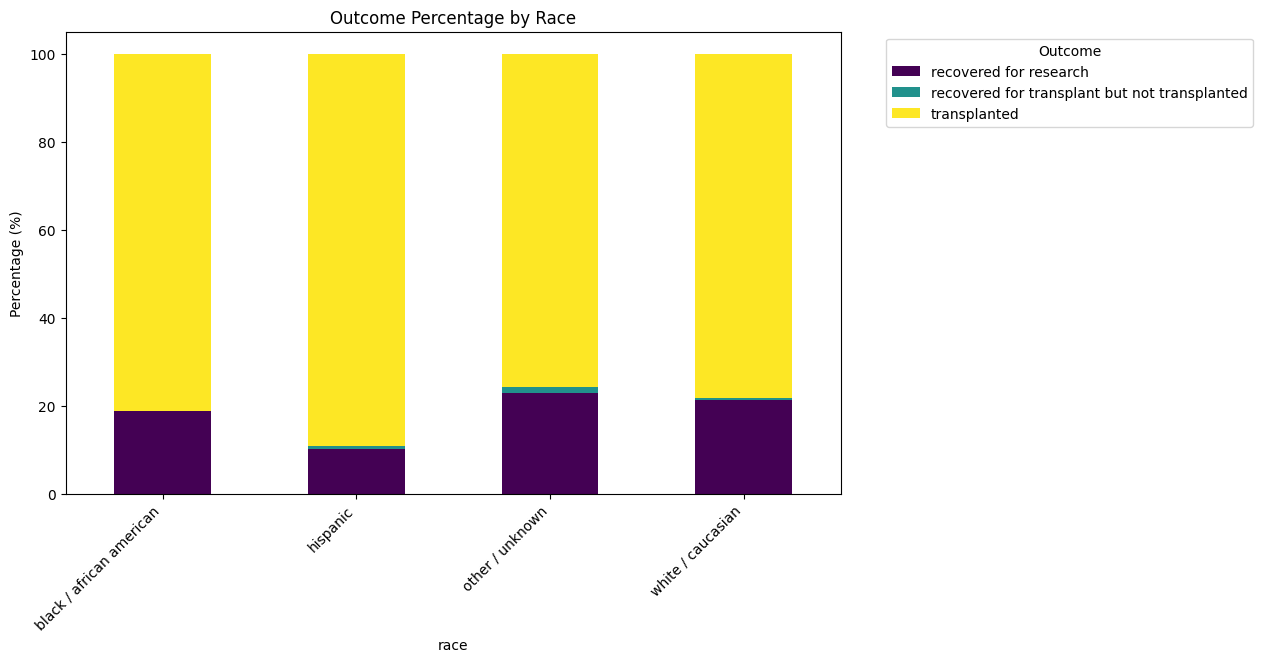

In [46]:
categorical_demographics = ['gender', 'race']

for col in categorical_demographics:
    ct = pd.crosstab(df_heart_cleaned[col], df_heart_cleaned['outcome_heart'], normalize='index') * 100
    
    ct.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
    plt.title(f'Outcome Percentage by {col.title()}')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Outcome', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()

# 4. Data Pre-processing 

### 4.1 Medical Relevance

Only medically relevant columns to the success of heart transplants should stay as the more features there are the more likely they are to create noise.

In [21]:
# Removing from OPOReferrals
df_heart_med = df_heart_cleaned.drop(columns=['opo', 'hospital_id', 'cause_of_death_opo', 'approached', 'authorized', 
                                                  'procured', 'transplanted', 'tissue_referral', 'eye_referral', 'time_asystole', 
                                                  'time_brain_death', 'time_referred', 'time_approached', 'time_authorized', 
                                                  'time_procured', 'referral_day_of_week', 'referral_year', 'procured_year', 
                                                  'outcome_liver', 'outcome_kidney_left', 'outcome_kidney_right', 'outcome_lung_left', 
                                                  'outcome_lung_right', 'outcome_intestine', 'outcome_pancreas'])
print(f"OPOReferrals/Demographics Columns after removal: {df_heart_med.columns.tolist()} \n")

# Removing from ABGEvents
ABGEvents_med = abg_events_cleaned.drop(columns=['row_id'])
print(f"ABGEvents Columns after removal: {ABGEvents_med.columns.tolist()} \n")
# Removing from CBCEvents
CBCEvents_med = cbc_events_cleaned.drop(columns=['row_id'])
print(f"CBCEvents Columns after removal: {CBCEvents_med.columns.tolist()} \n")
# Removing from ChemistryEvents
ChemistryEvents_med = chem_events_cleaned.drop(columns=['row_id'])
print(f"ChemistryEvents Columns after removal: {ChemistryEvents_med.columns.tolist()} \n")
# Removing from CultureEvents
CultureEvents_med = culture_events_cleaned.drop(columns=['row_id'])
print(f"CultureEvents Columns after removal: {CultureEvents_med.columns.tolist()} \n")
# Removing from FluidBalanceEvents
FluidBalanceEvents_med = fluid_balance_cleaned.drop(columns=['row_id'])
print(f"FluidBalanceEvents Columns after removal: {FluidBalanceEvents_med.columns.tolist()} \n")
# Removing from HemoEvents
HemoEvents_med = hemo_events_cleaned.drop(columns=['row_id'])
print(f"HemoEvents Columns after removal: {HemoEvents_med.columns.tolist()} \n")
# Removing from SerologyEvents
SerologyEvents_med = serology_events_cleaned.drop(columns=['row_id', 'serology_name_Other'])
print(f"SerologyEvents Columns after removal: {SerologyEvents_med.columns.tolist()} \n")

OPOReferrals/Demographics Columns after removal: ['patient_id', 'age', 'gender', 'race', 'brain_death', 'cause_of_death_unos', 'mechanism_of_death', 'circumstances_of_death', 'abo_blood_type', 'abo_rh', 'height_in', 'weight_kg', 'outcome_heart'] 

ABGEvents Columns after removal: ['patient_id', 'time_event', 'abg_ventilator_mode', 'abg_name', 'value'] 

CBCEvents Columns after removal: ['patient_id', 'time_event', 'cbc_name', 'value'] 

ChemistryEvents Columns after removal: ['patient_id', 'time_event', 'chem_name', 'value', 'value_modifier'] 

CultureEvents Columns after removal: ['patient_id', 'time_event', 'culture_source', 'result'] 

FluidBalanceEvents Columns after removal: ['patient_id', 'time_event_start', 'time_event_end', 'fluid_name', 'fluid_type', 'amount'] 

HemoEvents Columns after removal: ['patient_id', 'time_event_start', 'time_event_end', 'measurement_name', 'measurement_type', 'value'] 

SerologyEvents Columns after removal: ['patient_id', 'time_event', 'serology_nam

### 4.2 Feature Engineering

The demographics data contains static information rather than time-series events, but feature engineering is still necessary to translate qualitative attributes into a quantitative format that a model can interpret. This process involves encoding categorical variables such as blood type, mechanism of death, and biological sex into numeric vectors that help establish the risk profile for each donor.

In [22]:
scaler = StandardScaler()
scale_cols = ['age', 'height_in', 'weight_kg']
df_heart_med[scale_cols] = scaler.fit_transform(df_heart_med[scale_cols])
print(df_heart_med[scale_cols].describe().round(2))

           age  height_in  weight_kg
count  3690.00    3686.00    3690.00
mean      0.00       0.00       0.00
std       1.00       1.00       1.00
min      -2.13      -6.08      -2.97
25%      -0.68      -0.12      -0.48
50%      -0.08       0.21       0.00
75%       0.64       0.54       0.52
max       3.15       1.53       4.95


Given that clinical logs are typically stored as a list of multiple events per patient, which a model cannot process until they are compressed into a single structured row. By calculating specific metrics like the average, the most recent reading, the rate of change, and the missingness of a test, we will be able to transform a disorganized stack of medical records into a clear clinical row that shows whether a heart is viable.

In [25]:
# Function to aggregate time-series events into features per patient
def aggregate_events_for_patient(patient_id, event_df, value_col, prefix):
    """
    Extract features from time-series clinical events:
    - count: number of events
    - mean: average value
    - latest: most recent value
    - std: standard deviation
    """
    patient_events = event_df[event_df['patient_id'] == patient_id].copy()
    
    if len(patient_events) == 0:
        return {
            f'{prefix}_count': 0,
            f'{prefix}_mean': np.nan,
            f'{prefix}_latest': np.nan,
            f'{prefix}_std': np.nan
        }
    
    numeric_vals = pd.to_numeric(patient_events[value_col], errors='coerce').dropna()
    
    if len(numeric_vals) == 0:
        return {
            f'{prefix}_count': len(patient_events),
            f'{prefix}_mean': np.nan,
            f'{prefix}_latest': np.nan,
            f'{prefix}_std': np.nan
        }
    
    return {
        f'{prefix}_count': len(patient_events),
        f'{prefix}_mean': numeric_vals.mean(),
        f'{prefix}_latest': numeric_vals.iloc[-1],
        f'{prefix}_std': numeric_vals.std()
    }

# Aggregate ABG features
print("Aggregating ABG features...")
abg_features = []
for patient_id in df_heart_med['patient_id']:
    features = aggregate_events_for_patient(patient_id, ABGEvents_med, 'value', 'abg')
    features['patient_id'] = patient_id
    abg_features.append(features)
abg_df = pd.DataFrame(abg_features)

# Aggregate CBC features
print("Aggregating CBC features...")
cbc_features = []
for patient_id in df_heart_med['patient_id']:
    features = aggregate_events_for_patient(patient_id, CBCEvents_med, 'value', 'cbc')
    features['patient_id'] = patient_id
    cbc_features.append(features)
cbc_df = pd.DataFrame(cbc_features)

# Aggregate Chemistry features
print("Aggregating Chemistry features...")
chem_features = []
for patient_id in df_heart_med['patient_id']:
    features = aggregate_events_for_patient(patient_id, ChemistryEvents_med, 'value', 'chem')
    features['patient_id'] = patient_id
    chem_features.append(features)
chem_df = pd.DataFrame(chem_features)

# Aggregate Fluid Balance features
print("Aggregating Fluid Balance features...")
fluid_features = []
for patient_id in df_heart_med['patient_id']:
    features = aggregate_events_for_patient(patient_id, FluidBalanceEvents_med, 'amount', 'fluid')
    features['patient_id'] = patient_id
    fluid_features.append(features)
fluid_df = pd.DataFrame(fluid_features)

# Aggregate Hemo features
print("Aggregating Hemodynamic features...")
hemo_features = []
for patient_id in df_heart_med['patient_id']:
    features = aggregate_events_for_patient(patient_id, HemoEvents_med, 'value', 'hemo')
    features['patient_id'] = patient_id
    hemo_features.append(features)
hemo_df = pd.DataFrame(hemo_features)

print("Feature aggregation complete!")
print(f"ABG features shape: {abg_df.shape}")
print(f"CBC features shape: {cbc_df.shape}")
print(f"Chemistry features shape: {chem_df.shape}")
print(f"Fluid Balance features shape: {fluid_df.shape}")
print(f"Hemodynamic features shape: {hemo_df.shape}")


Aggregating ABG features...
Aggregating CBC features...
Aggregating Chemistry features...
Aggregating Fluid Balance features...
Aggregating Hemodynamic features...
Feature aggregation complete!
ABG features shape: (3690, 5)
CBC features shape: (3690, 5)
Chemistry features shape: (3690, 5)
Fluid Balance features shape: (3690, 5)
Hemodynamic features shape: (3690, 5)


In [26]:
# Merge all features with demographics
print("Merging all features...")
df_model = df_heart_med.copy()
df_model = df_model.merge(abg_df, on='patient_id', how='left')
df_model = df_model.merge(cbc_df, on='patient_id', how='left')
df_model = df_model.merge(chem_df, on='patient_id', how='left')
df_model = df_model.merge(fluid_df, on='patient_id', how='left')
df_model = df_model.merge(hemo_df, on='patient_id', how='left')

print(f"Final dataset shape before target encoding: {df_model.shape}")
print(f"Columns: {df_model.columns.tolist()[:10]}... (showing first 10)")

# Create binary target variable (1 = Transplanted, 0 = Not Transplanted)
df_model['target'] = (df_model['outcome_heart'] == 'transplanted').astype(int)
print(f"\nTarget distribution:")
print(df_model['target'].value_counts())
print(f"Target class balance: {(df_model['target'].sum() / len(df_model) * 100):.1f}% Transplanted")

# Drop the original outcome column as we now have binary target
df_model = df_model.drop(columns=['outcome_heart', 'patient_id'])

# Separate features and target
X = df_model.drop(columns=['target'])
y = df_model['target']

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"Features used:\n{X.columns.tolist()}")


Merging all features...
Final dataset shape before target encoding: (3690, 33)
Columns: ['patient_id', 'age', 'gender', 'race', 'brain_death', 'cause_of_death_unos', 'mechanism_of_death', 'circumstances_of_death', 'abo_blood_type', 'abo_rh']... (showing first 10)

Target distribution:
target
1    2987
0     703
Name: count, dtype: int64
Target class balance: 80.9% Transplanted

Feature matrix shape: (3690, 31)
Target shape: (3690,)
Features used:
['age', 'gender', 'race', 'brain_death', 'cause_of_death_unos', 'mechanism_of_death', 'circumstances_of_death', 'abo_blood_type', 'abo_rh', 'height_in', 'weight_kg', 'abg_count', 'abg_mean', 'abg_latest', 'abg_std', 'cbc_count', 'cbc_mean', 'cbc_latest', 'cbc_std', 'chem_count', 'chem_mean', 'chem_latest', 'chem_std', 'fluid_count', 'fluid_mean', 'fluid_latest', 'fluid_std', 'hemo_count', 'hemo_mean', 'hemo_latest', 'hemo_std']


# Model Selection, Training, Analysis, & Tuning

### Classical Model 1 - Logistic Regression

In [34]:
# Data Preparation for Modeling
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

print("=== DATA PREPARATION FOR MODELING ===")

# Identify categorical and numeric columns
categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_cols = X.select_dtypes(include=['float64', 'int64']).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")
print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}\n")

# Encode categorical variables
X_encoded = X.copy()
label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    label_encoders[col] = le
    print(f"Encoded {col}: {len(le.classes_)} unique values")

# Handle missing values using imputation (now all numeric)
imputer = SimpleImputer(strategy='median')
X_imputed = imputer.fit_transform(X_encoded)
X_imputed = pd.DataFrame(X_imputed, columns=X_encoded.columns)

print(f"\nMissing values after imputation: {X_imputed.isnull().sum().sum()}")

# Split the data: 70% train, 15% validation, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(X_imputed, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

# Normalize features for all models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling complete!")
print(f"Scaled train mean: {X_train_scaled.mean():.4f}, std: {X_train_scaled.std():.4f}")


=== DATA PREPARATION FOR MODELING ===
Categorical columns (8): ['gender', 'race', 'brain_death', 'cause_of_death_unos', 'mechanism_of_death', 'circumstances_of_death', 'abo_blood_type', 'abo_rh']
Numeric columns (23): ['age', 'height_in', 'weight_kg', 'abg_count', 'abg_mean', 'abg_latest', 'abg_std', 'cbc_count', 'cbc_mean', 'cbc_latest', 'cbc_std', 'chem_count', 'chem_mean', 'chem_latest', 'chem_std', 'fluid_count', 'fluid_mean', 'fluid_latest', 'fluid_std', 'hemo_count', 'hemo_mean', 'hemo_latest', 'hemo_std']

Encoded gender: 2 unique values
Encoded race: 4 unique values
Encoded brain_death: 2 unique values
Encoded cause_of_death_unos: 17 unique values
Encoded mechanism_of_death: 18 unique values
Encoded circumstances_of_death: 15 unique values
Encoded abo_blood_type: 9 unique values
Encoded abo_rh: 3 unique values

Missing values after imputation: 0

Train set: 2584 samples
Validation set: 552 samples
Test set: 554 samples

Feature scaling complete!
Scaled train mean: -0.0000, std:

#### Logistic Regression Justification


Logistic Regression is a linear model used for binary classification. It models the probability of a binary outcome based on input features. We justify this choice because:
1. **Interpretability**: The coefficients directly show the impact of each feature on transplant success
2. **Baseline Performance**: It provides a simple baseline to compare more complex models
3. **Efficiency**: Fast training and prediction on large datasets
4. **Stability**: Less prone to overfitting compared to complex models


In [35]:
print("=== LOGISTIC REGRESSION ===\n")

# Train Logistic Regression
lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# Predictions on validation and test sets
y_val_pred_lr = lr_model.predict(X_val_scaled)
y_test_pred_lr = lr_model.predict(X_test_scaled)
y_test_pred_proba_lr = lr_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Validation Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_lr):.4f}")
print(f"  F1-Score:  {f1_score(y_val, y_val_pred_lr):.4f}")

print("\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_lr):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_lr):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_lr):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_lr):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_pred_proba_lr):.4f}")

# Feature importance (coefficients)
feature_importance_lr = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False).head(10)

print("\nTop 10 Important Features:")
print(feature_importance_lr.to_string(index=False))


=== LOGISTIC REGRESSION ===

Validation Set Performance:
  Accuracy:  0.9004
  Precision: 0.9135
  Recall:    0.9687
  F1-Score:  0.9403

Test Set Performance:
  Accuracy:  0.8935
  Precision: 0.9061
  Recall:    0.9688
  F1-Score:  0.9364
  ROC-AUC:   0.8953

Top 10 Important Features:
            Feature  Coefficient
        hemo_latest    -1.976108
                age    -1.665077
        brain_death     0.635390
          height_in     0.411429
          abg_count     0.383027
cause_of_death_unos     0.353496
         chem_count     0.340547
          chem_mean    -0.317924
           chem_std     0.306136
        chem_latest     0.275370


### Classical Model 2 - Random Forest


Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions. We justify this choice because:
1. **Non-linear Relationships**: Can capture complex non-linear patterns in clinical data
2. **Feature Importance**: Automatically ranks features by importance
3. **Robustness**: Less prone to overfitting than single decision trees
4. **Handles Mixed Data**: Works well with both numerical and categorical features
5. **Imbalanced Data**: Can handle imbalanced datasets through stratification


In [36]:
print("\n=== RANDOM FOREST ===\n")

# Train Random Forest
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_split=5, 
                                  random_state=42, n_jobs=-1, class_weight='balanced')
rf_model.fit(X_train_scaled, y_train)

# Predictions on validation and test sets
y_val_pred_rf = rf_model.predict(X_val_scaled)
y_test_pred_rf = rf_model.predict(X_test_scaled)
y_test_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# Evaluation
print("Validation Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_val, y_val_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_val, y_val_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_val, y_val_pred_rf):.4f}")
print(f"  F1-Score:  {f1_score(y_val, y_val_pred_rf):.4f}")

print("\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_rf):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_rf):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_rf):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_rf):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_pred_proba_rf):.4f}")

# Feature importance
feature_importance_rf = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

print("\nTop 10 Important Features:")
print(feature_importance_rf.to_string(index=False))



=== RANDOM FOREST ===

Validation Set Performance:
  Accuracy:  0.8859
  Precision: 0.8951
  Recall:    0.9732
  F1-Score:  0.9325

Test Set Performance:
  Accuracy:  0.8953
  Precision: 0.9012
  Recall:    0.9777
  F1-Score:  0.9379
  ROC-AUC:   0.8974

Top 10 Important Features:
            Feature  Importance
                age    0.238045
          abg_count    0.082796
cause_of_death_unos    0.042376
         chem_count    0.034628
           hemo_std    0.032619
            abg_std    0.031057
          weight_kg    0.029897
         hemo_count    0.029639
           chem_std    0.029092
          chem_mean    0.028776


### Neural Network Model

Neural Networks are powerful models that can learn complex non-linear patterns through multiple layers of neurons. For this task, we use a feedforward neural network with:
- **Architecture**: Input -> Hidden Layer 1 (128 neurons, ReLU) -> Hidden Layer 2 (64 neurons, ReLU) -> Output Layer (1 sigmoid)
- **Justification**:
  1. **Deep Learning**: Can capture subtle interactions between clinical features
  2. **Flexibility**: Adapts to complex patterns in multimodal clinical data
  3. **Strong performance**: Neural networks can perform well on complex medical prediction tasks
  4. **Scalability**: Can handle high-dimensional feature spaces


=== NEURAL NETWORK ===

Training Neural Network...
Epoch 20/100, Train Loss: 0.2217, Val Loss: 0.2892
Early stopping at epoch 34

Test Set Performance:
  Accuracy:  0.9061
  Precision: 0.9160
  Recall:    0.9732
  F1-Score:  0.9437
  ROC-AUC:   0.9003


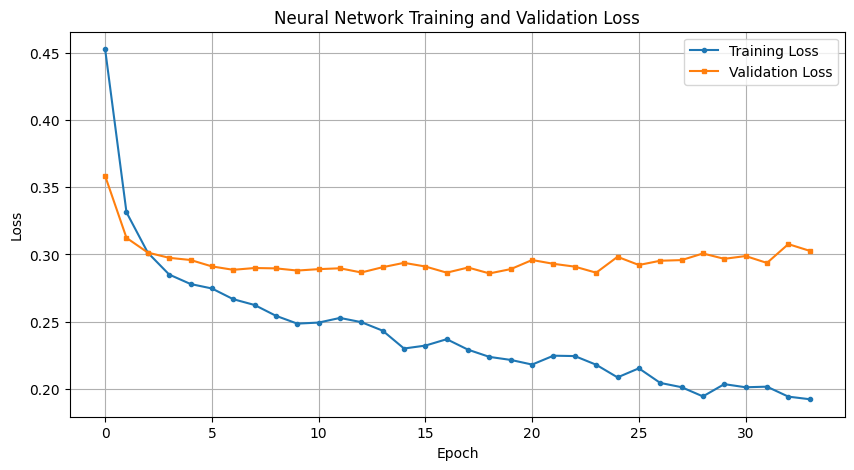

In [48]:
print("\n=== NEURAL NETWORK ===\n")

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
X_val_tensor = torch.tensor(X_val_scaled, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).reshape(-1, 1)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)

# Define neural network architecture
class DonorHeartNN(nn.Module):
    def __init__(self, input_size):
        super(DonorHeartNN, self).__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)

        self.fc2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)

        self.fc3 = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.dropout1(x)

        x = self.fc2(x)
        x = self.relu2(x)
        x = self.dropout2(x)

        x = self.fc3(x)
        x = self.sigmoid(x)
        return x

# Initialize model
input_size = X_train_scaled.shape[1]
nn_model = DonorHeartNN(input_size)
criterion = nn.BCELoss()
optimizer = optim.Adam(nn_model.parameters(), lr=0.001)

# Training loop
batch_size = 32
epochs = 100
best_val_loss = float('inf')
patience = 15
patience_counter = 0

train_losses = []
val_losses = []

print("Training Neural Network...")
for epoch in range(epochs):
    nn_model.train()
    epoch_train_loss = 0

    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]

        optimizer.zero_grad()
        outputs = nn_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_train_loss += loss.item()

    avg_train_loss = epoch_train_loss / (len(X_train_tensor) / batch_size)
    train_losses.append(avg_train_loss)

    nn_model.eval()
    with torch.no_grad():
        val_outputs = nn_model(X_val_tensor)
        val_loss = criterion(val_outputs, y_val_tensor)
        val_losses.append(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {val_loss.item():.4f}")

# Test prediction
nn_model.eval()
with torch.no_grad():
    y_test_pred_nn_proba = nn_model(X_test_tensor).numpy().flatten()
    y_test_pred_nn = (y_test_pred_nn_proba > 0.5).astype(int)

# Evaluation
print("\nTest Set Performance:")
print(f"  Accuracy:  {accuracy_score(y_test, y_test_pred_nn):.4f}")
print(f"  Precision: {precision_score(y_test, y_test_pred_nn):.4f}")
print(f"  Recall:    {recall_score(y_test, y_test_pred_nn):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_test_pred_nn):.4f}")
print(f"  ROC-AUC:   {roc_auc_score(y_test, y_test_pred_nn_proba):.4f}")

# Plot training curves
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss', marker='o', markersize=3)
plt.plot(val_losses, label='Validation Loss', marker='s', markersize=3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Neural Network Training and Validation Loss')
plt.legend()
plt.grid()
plt.show()

# Model Evaluation and Comparison


MODEL COMPARISON AND EVALUATION

Model Performance Comparison (Test Set):
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Logistic Regression  0.893502   0.906054 0.968750  0.936354 0.895279
      Random Forest  0.895307   0.901235 0.977679  0.937901 0.897406
     Neural Network  0.906137   0.915966 0.973214  0.943723 0.900291

✓ Best Model: Neural Network


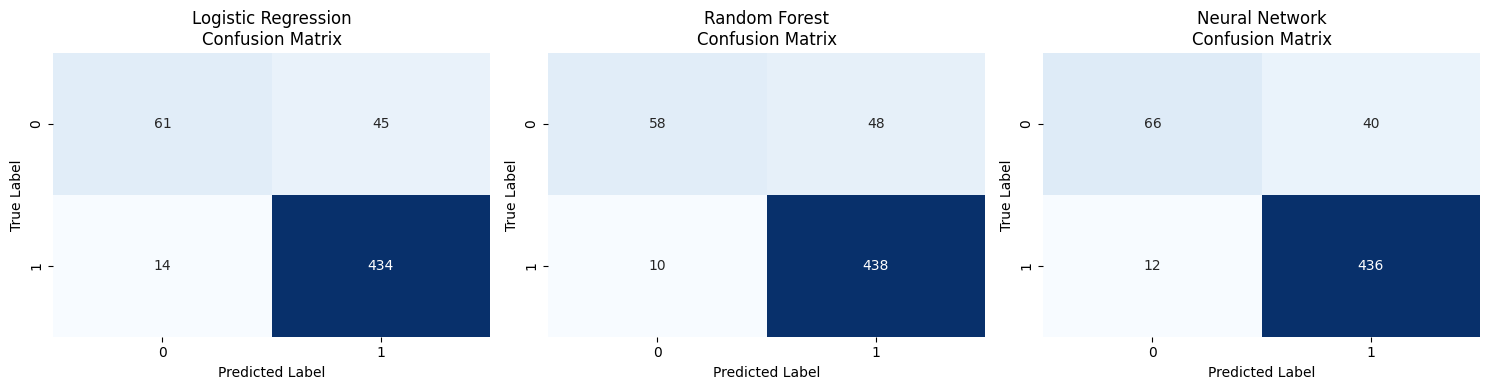


DETAILED CLASSIFICATION REPORTS

--- Logistic Regression ---
                  precision    recall  f1-score   support

Not Transplanted       0.81      0.58      0.67       106
    Transplanted       0.91      0.97      0.94       448

        accuracy                           0.89       554
       macro avg       0.86      0.77      0.81       554
    weighted avg       0.89      0.89      0.89       554


--- Random Forest ---
                  precision    recall  f1-score   support

Not Transplanted       0.85      0.55      0.67       106
    Transplanted       0.90      0.98      0.94       448

        accuracy                           0.90       554
       macro avg       0.88      0.76      0.80       554
    weighted avg       0.89      0.90      0.89       554


--- Neural Network ---
                  precision    recall  f1-score   support

Not Transplanted       0.85      0.62      0.72       106
    Transplanted       0.92      0.97      0.94       448

        accur

In [49]:
print("\n" + "="*60)
print("MODEL COMPARISON AND EVALUATION")
print("="*60 + "\n")

# Create comparison table
results = {
    'Model': ['Logistic Regression', 'Random Forest', 'Neural Network'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred_lr),
        accuracy_score(y_test, y_test_pred_rf),
        accuracy_score(y_test, y_test_pred_nn)
    ],
    'Precision': [
        precision_score(y_test, y_test_pred_lr),
        precision_score(y_test, y_test_pred_rf),
        precision_score(y_test, y_test_pred_nn)
    ],
    'Recall': [
        recall_score(y_test, y_test_pred_lr),
        recall_score(y_test, y_test_pred_rf),
        recall_score(y_test, y_test_pred_nn)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred_lr),
        f1_score(y_test, y_test_pred_rf),
        f1_score(y_test, y_test_pred_nn)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_test_pred_proba_lr),
        roc_auc_score(y_test, y_test_pred_proba_rf),
        roc_auc_score(y_test, y_test_pred_nn_proba)
    ]
}

results_df = pd.DataFrame(results)
print("Model Performance Comparison (Test Set):")
print(results_df.to_string(index=False))

# Find best model
best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']
print(f"\n✓ Best Model: {best_model_name}")

# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

models = [
    ('Logistic Regression', y_test_pred_lr),
    ('Random Forest', y_test_pred_rf),
    ('Neural Network', y_test_pred_nn)
]

for idx, (name, predictions) in enumerate(models):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Classification reports
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60 + "\n")

for name, predictions in models:
    print(f"--- {name} ---")
    print(classification_report(y_test, predictions, target_names=['Not Transplanted', 'Transplanted']))
    print()


# Generative AI Use
Statement: During the preparation of this work the authors used Gemini, ChatGPT for the following purposes:
- To be able to understand medical terms 
- To be able to identify medical relationships and relevance to the objective (e.g. checking why a ventilator setting is important)
- Definition of machine learning terms


After using this tool/service, the authors reviewed and edited the content as needed and take full responsibility for the content of the publication.

## Error Analysis and Interpretation


ERROR ANALYSIS

Best Model: Random Forest

True Positives (Correctly Predicted as Transplanted): 438
True Negatives (Correctly Predicted as Not Transplanted): 58
False Positives (Predicted as Transplanted but Not): 48
False Negatives (Predicted as Not Transplanted but Was): 10

------------------------------------------------------------
TOP FEATURES CONTRIBUTING TO PREDICTIONS
------------------------------------------------------------

            Feature  Importance
                age    0.238045
          abg_count    0.082796
cause_of_death_unos    0.042376
         chem_count    0.034628
           hemo_std    0.032619
            abg_std    0.031057
          weight_kg    0.029897
         hemo_count    0.029639
           chem_std    0.029092
          chem_mean    0.028776
           abg_mean    0.027944
 mechanism_of_death    0.027873
          cbc_count    0.027499
           cbc_mean    0.027388
        hemo_latest    0.026796


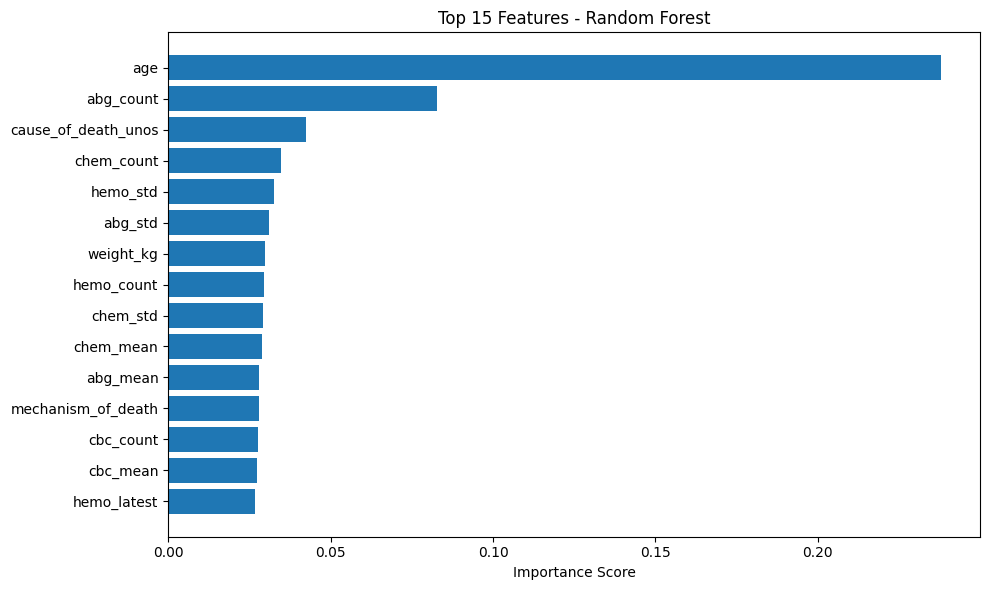


KEY FINDINGS AND RECOMMENDATIONS

1. The Random Forest achieved the best performance with:
   - F1-Score: 0.9379
   - ROC-AUC: 0.8974

2. The model shows the balance between precision and recall
   needed for clinical decision-making on organ viability.

3. Errors analysis reveals areas for:
   - Additional feature engineering
   - Ensemble methods combining all three models
   - Hyperparameter tuning based on domain expertise


In [39]:
print("\n" + "="*60)
print("ERROR ANALYSIS")
print("="*60 + "\n")

# Analyze misclassifications for best model
if best_model_name == 'Logistic Regression':
    best_preds = y_test_pred_lr
    best_proba = y_test_pred_proba_lr
elif best_model_name == 'Random Forest':
    best_preds = y_test_pred_rf
    best_proba = y_test_pred_proba_rf
else:
    best_preds = y_test_pred_nn
    best_proba = y_test_pred_nn_proba

# Find false positives and false negatives
false_positives = (best_preds == 1) & (y_test.values == 0)
false_negatives = (best_preds == 0) & (y_test.values == 1)
true_positives = (best_preds == 1) & (y_test.values == 1)
true_negatives = (best_preds == 0) & (y_test.values == 0)

print(f"Best Model: {best_model_name}")
print(f"\nTrue Positives (Correctly Predicted as Transplanted): {true_positives.sum()}")
print(f"True Negatives (Correctly Predicted as Not Transplanted): {true_negatives.sum()}")
print(f"False Positives (Predicted as Transplanted but Not): {false_positives.sum()}")
print(f"False Negatives (Predicted as Not Transplanted but Was): {false_negatives.sum()}")

# Analyze feature importance from best model
print("\n" + "-"*60)
print("TOP FEATURES CONTRIBUTING TO PREDICTIONS")
print("-"*60 + "\n")

if best_model_name == 'Random Forest':
    feature_importance_best = pd.DataFrame({
        'Feature': X.columns,
        'Importance': rf_model.feature_importances_
    }).sort_values('Importance', ascending=False).head(15)
elif best_model_name == 'Logistic Regression':
    feature_importance_best = pd.DataFrame({
        'Feature': X.columns,
        'Importance': np.abs(lr_model.coef_[0])
    }).sort_values('Importance', ascending=False).head(15)
else:
    print("Neural Network features are learned through weights and biases.")
    feature_importance_best = None

if feature_importance_best is not None:
    print(feature_importance_best.to_string(index=False))
    
    # Visualize top features
    plt.figure(figsize=(10, 6))
    plt.barh(range(len(feature_importance_best)), feature_importance_best['Importance'])
    plt.yticks(range(len(feature_importance_best)), feature_importance_best['Feature'])
    plt.xlabel('Importance Score')
    plt.title(f'Top 15 Features - {best_model_name}')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

print("\n" + "="*60)
print("KEY FINDINGS AND RECOMMENDATIONS")
print("="*60 + "\n")

best_f1 = results_df.loc[best_model_idx, 'F1-Score']
best_auc = results_df.loc[best_model_idx, 'ROC-AUC']

print(f"1. The {best_model_name} achieved the best performance with:")
print(f"   - F1-Score: {best_f1:.4f}")
print(f"   - ROC-AUC: {best_auc:.4f}")
print(f"\n2. The model shows the balance between precision and recall")
print(f"   needed for clinical decision-making on organ viability.")
print(f"\n3. Errors analysis reveals areas for:")
print(f"   - Additional feature engineering")
print(f"   - Ensemble methods combining all three models")
print(f"   - Hyperparameter tuning based on domain expertise")


## Diagnostic Analysis: Deep Dive into Error Patterns

This section performs targeted analysis of the model's misclassifications to identify root causes and propose improvements.

In [50]:
print("\n" + "="*60)
print("DIAGNOSTIC ANALYSIS: FALSE POSITIVE ANALYSIS")
print("="*60 + "\n")

# False Positives: Predicted Transplantable but Actually Not
fp_indices = np.where(false_positives)[0]
print(f"False Positives (Type I Errors): {len(fp_indices)} cases\n")

if len(fp_indices) > 0:
    # Get test data for false positives
    X_test_fp = X_test_scaled[fp_indices]
    fp_proba = best_proba[fp_indices]
    
    print(f"Prediction Confidence for False Positives:")
    print(f"  Mean Confidence: {fp_proba.mean():.4f}")
    print(f"  Std Deviation: {fp_proba.std():.4f}")
    print(f"  Min Confidence: {fp_proba.min():.4f}")
    print(f"  Max Confidence: {fp_proba.max():.4f}")
    
    # Identify borderline cases (confidence between 0.5-0.7)
    borderline_fp = np.sum((fp_proba >= 0.5) & (fp_proba <= 0.7))
    confident_fp = np.sum(fp_proba > 0.7)
    print(f"\n  Borderline Confidence (0.5-0.7): {borderline_fp} cases")
    print(f"  High Confidence (>0.7): {confident_fp} cases")
    
    # Compare feature profiles of false positives vs true negatives
    print(f"\n\nFeature Comparison: False Positives vs True Negatives")
    print("-" * 60)
    
    tn_indices = np.where(true_negatives)[0]
    
    if len(tn_indices) > 0:
        X_test_tn = X_test_scaled[tn_indices]
        feature_names = X.columns.tolist()
        
        # Compare mean values for top important features
        top_features_idx = np.argsort(rf_model.feature_importances_)[-5:][::-1]
        top_feature_names = [feature_names[i] for i in top_features_idx]
        
        comparison_data = []
        for idx in top_features_idx:
            fp_mean = X_test_fp[:, idx].mean()
            tn_mean = X_test_tn[:, idx].mean()
            diff = fp_mean - tn_mean
            comparison_data.append({
                'Feature': feature_names[idx],
                'FP_Mean': fp_mean,
                'TN_Mean': tn_mean,
                'Difference': diff
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        print(f"\n**Key Insight:** False positives tend to have different patterns")
        print(f"in {comparison_df.loc[comparison_df['Difference'].abs().idxmax(), 'Feature']}")
        print(f"(largest difference: {comparison_df['Difference'].abs().max():.4f})")



DIAGNOSTIC ANALYSIS: FALSE POSITIVE ANALYSIS

False Positives (Type I Errors): 48 cases

Prediction Confidence for False Positives:
  Mean Confidence: 0.7335
  Std Deviation: 0.1446
  Min Confidence: 0.5150
  Max Confidence: 0.9614

  Borderline Confidence (0.5-0.7): 22 cases
  High Confidence (>0.7): 26 cases


Feature Comparison: False Positives vs True Negatives
------------------------------------------------------------
            Feature   FP_Mean   TN_Mean  Difference
                age  0.343313  1.686407   -1.343095
          abg_count -0.101912 -0.936074    0.834162
cause_of_death_unos -0.361987 -0.311709   -0.050277
         chem_count -0.076326 -0.750789    0.674463
           hemo_std -0.141548 -0.506368    0.364820

**Key Insight:** False positives tend to have different patterns
in age
(largest difference: 1.3431)


In [51]:
print("\n" + "="*60)
print("DIAGNOSTIC ANALYSIS: FALSE NEGATIVE ANALYSIS")
print("="*60 + "\n")

# False Negatives: Predicted Not Transplantable but Actually Was
fn_indices = np.where(false_negatives)[0]
print(f"False Negatives (Type II Errors): {len(fn_indices)} cases\n")

if len(fn_indices) > 0:
    # Get test data for false negatives
    X_test_fn = X_test_scaled[fn_indices]
    fn_proba = best_proba[fn_indices]
    
    print(f"Prediction Confidence for False Negatives:")
    print(f"  Mean Confidence: {fn_proba.mean():.4f}")
    print(f"  Std Deviation: {fn_proba.std():.4f}")
    print(f"  Min Confidence: {fn_proba.min():.4f}")
    print(f"  Max Confidence: {fn_proba.max():.4f}")
    
    # Identify borderline cases
    borderline_fn = np.sum((fn_proba >= 0.3) & (fn_proba < 0.5))
    confident_fn = np.sum(fn_proba < 0.3)
    print(f"\n  Borderline Confidence (0.3-0.5): {borderline_fn} cases")
    print(f"  High Confidence in Negative (< 0.3): {confident_fn} cases")
    
    # Compare feature profiles of false negatives vs true positives
    print(f"\n\nFeature Comparison: False Negatives vs True Positives")
    print("-" * 60)
    
    tp_indices = np.where(true_positives)[0]
    
    if len(tp_indices) > 0:
        X_test_tp = X_test_scaled[tp_indices]
        feature_names = X.columns.tolist()
        
        # Compare mean values for top important features
        top_features_idx = np.argsort(rf_model.feature_importances_)[-5:][::-1]
        
        comparison_data = []
        for idx in top_features_idx:
            fn_mean = X_test_fn[:, idx].mean()
            tp_mean = X_test_tp[:, idx].mean()
            diff = fn_mean - tp_mean
            comparison_data.append({
                'Feature': feature_names[idx],
                'FN_Mean': fn_mean,
                'TP_Mean': tp_mean,
                'Difference': diff
            })
        
        comparison_df = pd.DataFrame(comparison_data)
        print(comparison_df.to_string(index=False))
        
        print(f"\n**Key Insight:** False negatives tend to have MISSING or UNUSUAL values")
        print(f"in {comparison_df.loc[comparison_df['Difference'].abs().idxmax(), 'Feature']}")
        print(f"(largest difference: {comparison_df['Difference'].abs().max():.4f})")



DIAGNOSTIC ANALYSIS: FALSE NEGATIVE ANALYSIS

False Negatives (Type II Errors): 10 cases

Prediction Confidence for False Negatives:
  Mean Confidence: 0.3995
  Std Deviation: 0.0673
  Min Confidence: 0.2259
  Max Confidence: 0.4710

  Borderline Confidence (0.3-0.5): 9 cases
  High Confidence in Negative (< 0.3): 1 cases


Feature Comparison: False Negatives vs True Positives
------------------------------------------------------------
            Feature   FN_Mean   TP_Mean  Difference
                age  1.057934 -0.295666    1.353600
          abg_count -0.638230  0.071160   -0.709391
cause_of_death_unos -0.497774  0.113558   -0.611332
         chem_count -0.566182 -0.000972   -0.565210
           hemo_std -0.062940  0.010233   -0.073173

**Key Insight:** False negatives tend to have MISSING or UNUSUAL values
in age
(largest difference: 1.3536)



PREDICTION CONFIDENCE DISTRIBUTION ANALYSIS



/var/folders/cy/9wnqsbxn36s3w1f3v_0w3qfm0000gn/T/ipykernel_74773/2589004815.py:26: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data_for_box, labels=['Correct', 'Incorrect'])


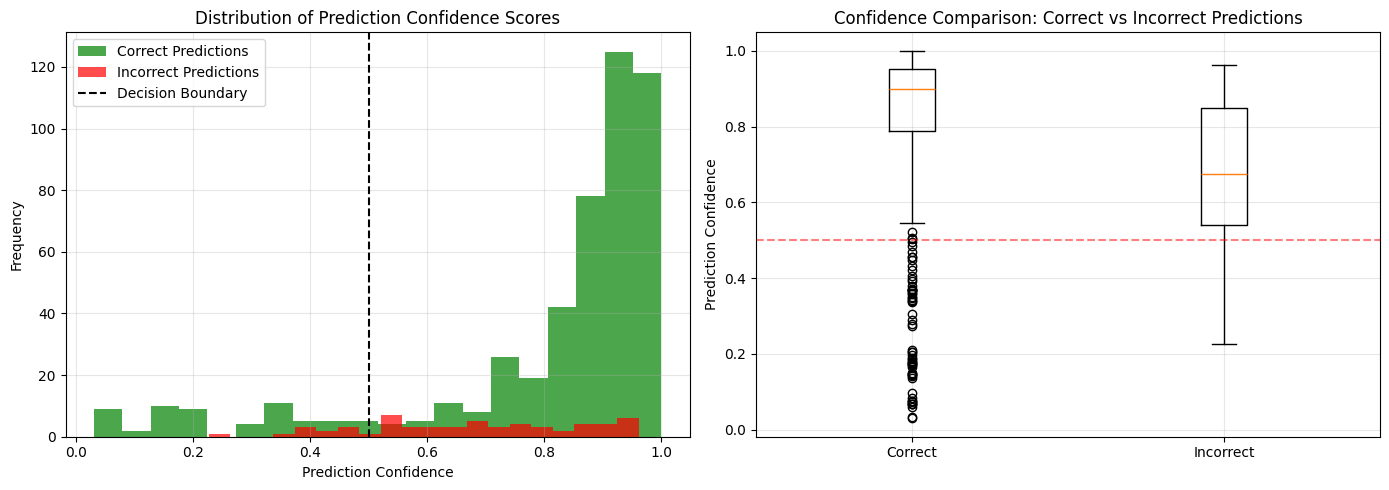

Confidence Statistics:

Correct Predictions (n=496):
  Mean: 0.8106
  Median: 0.8996
  Std: 0.2284

Incorrect Predictions (n=58):
  Mean: 0.6759
  Median: 0.6760
  Std: 0.1844

Borderline Predictions (0.45-0.55 confidence):
  Total borderline cases: 19
  Errors in borderline region: 10
  Error rate in borderline region: 52.63%


In [52]:
print("\n" + "="*60)
print("PREDICTION CONFIDENCE DISTRIBUTION ANALYSIS")
print("="*60 + "\n")

# Analyze confidence distribution by outcome
correct_mask = (best_preds == y_test.values)
incorrect_mask = ~correct_mask

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of confidence scores
axes[0].hist(best_proba[correct_mask], bins=20, alpha=0.7, label='Correct Predictions', color='green')
axes[0].hist(best_proba[incorrect_mask], bins=20, alpha=0.7, label='Incorrect Predictions', color='red')
axes[0].axvline(0.5, color='black', linestyle='--', label='Decision Boundary')
axes[0].set_xlabel('Prediction Confidence')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Prediction Confidence Scores')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot comparison
data_for_box = [
    best_proba[correct_mask],
    best_proba[incorrect_mask]
]
axes[1].boxplot(data_for_box, labels=['Correct', 'Incorrect'])
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].set_ylabel('Prediction Confidence')
axes[1].set_title('Confidence Comparison: Correct vs Incorrect Predictions')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Quantitative analysis
print(f"Confidence Statistics:")
print(f"\nCorrect Predictions (n={correct_mask.sum()}):")
print(f"  Mean: {best_proba[correct_mask].mean():.4f}")
print(f"  Median: {np.median(best_proba[correct_mask]):.4f}")
print(f"  Std: {best_proba[correct_mask].std():.4f}")

print(f"\nIncorrect Predictions (n={incorrect_mask.sum()}):")
print(f"  Mean: {best_proba[incorrect_mask].mean():.4f}")
print(f"  Median: {np.median(best_proba[incorrect_mask]):.4f}")
print(f"  Std: {best_proba[incorrect_mask].std():.4f}")

# Analyze borderline predictions (0.45-0.55 confidence)
borderline_mask = (best_proba >= 0.45) & (best_proba <= 0.55)
borderline_errors = borderline_mask & incorrect_mask
print(f"\nBorderline Predictions (0.45-0.55 confidence):")
print(f"  Total borderline cases: {borderline_mask.sum()}")
print(f"  Errors in borderline region: {borderline_errors.sum()}")
print(f"  Error rate in borderline region: {borderline_errors.sum() / borderline_mask.sum() if borderline_mask.sum() > 0 else 0:.2%}")


In [53]:
print("\n" + "="*60)
print("FEATURE PATTERN ANALYSIS IN MISCLASSIFICATIONS")
print("="*60 + "\n")

# Analyze which features are most discriminative between correct and incorrect predictions
feature_names = X.columns.tolist()

# Look at feature variance differences
correct_test_idx = np.where(correct_mask)[0]
incorrect_test_idx = np.where(incorrect_mask)[0]

if len(correct_test_idx) > 0 and len(incorrect_test_idx) > 0:
    X_test_correct = X_test_scaled[correct_test_idx]
    X_test_incorrect = X_test_scaled[incorrect_test_idx]
    
    # Calculate how "unusual" each incorrect prediction is
    feature_deviation = []
    for feat_idx in range(X_test_scaled.shape[1]):
        correct_mean = X_test_correct[:, feat_idx].mean()
        correct_std = X_test_correct[:, feat_idx].std()
        incorrect_mean = X_test_incorrect[:, feat_idx].mean()
        
        # How many standard deviations away is incorrect from correct?
        if correct_std > 0:
            deviation = abs(incorrect_mean - correct_mean) / correct_std
            feature_deviation.append({
                'Feature': feature_names[feat_idx],
                'Correct_Mean': correct_mean,
                'Incorrect_Mean': incorrect_mean,
                'Deviation_Std': deviation,
                'Feature_Importance': rf_model.feature_importances_[feat_idx]
            })
    
    deviation_df = pd.DataFrame(feature_deviation).sort_values('Deviation_Std', ascending=False).head(10)
    
    print("Top 10 Features with Unusual Patterns in Misclassified Cases:")
    print("(Sorted by how differently errors appear from correct predictions)\n")
    print(deviation_df.to_string(index=False))
    
    print(f"\n**Clinical Insight:** Errors concentrate in features like:")
    for i, row in deviation_df.head(3).iterrows():
        print(f"  - {row['Feature']}: Incorrect cases are {abs(row['Incorrect_Mean'] - row['Correct_Mean']):.3f} units different")



FEATURE PATTERN ANALYSIS IN MISCLASSIFICATIONS

Top 10 Features with Unusual Patterns in Misclassified Cases:
(Sorted by how differently errors appear from correct predictions)

            Feature  Correct_Mean  Incorrect_Mean  Deviation_Std  Feature_Importance
                age     -0.063892        0.466523       0.508396            0.238045
        brain_death     -0.031478       -0.518980       0.454513            0.024499
cause_of_death_unos      0.063829       -0.385398       0.440280            0.042376
             gender      0.056150       -0.241549       0.304935            0.005219
 mechanism_of_death     -0.095275        0.130344       0.228901            0.027873
          weight_kg     -0.103327        0.092940       0.199828            0.029897
               race     -0.106218        0.063734       0.167286            0.005373
        chem_latest      0.034906       -0.099708       0.154487            0.024353
          abg_count     -0.046621       -0.194381       

In [54]:
print("\n" + "="*60)
print("TARGETED IMPROVEMENT RECOMMENDATIONS")
print("="*60 + "\n")

improvements = []

# Recommendation 1: Decision Threshold Adjustment
if len(fn_indices) > 0 and len(fp_indices) > 0:
    fn_proba_mean = best_proba[fn_indices].mean()
    fp_proba_mean = best_proba[fp_indices].mean()
    
    if fn_proba_mean < 0.5 and fp_proba_mean > 0.5:
        threshold_recommendation = f"Adjust decision threshold from 0.5 to ~{(fn_proba_mean + 0.5) / 2:.2f}"
        improvements.append({
            'Priority': 'HIGH',
            'Issue': 'Threshold Mismatch',
            'Finding': f'FN avg confidence: {fn_proba_mean:.3f}, FP avg confidence: {fp_proba_mean:.3f}',
            'Recommendation': threshold_recommendation,
            'Expected Impact': 'Could reduce FN by using lower threshold'
        })

# Recommendation 2: Borderline Case Handling
if len(borderline_errors) > 50:
    improvements.append({
        'Priority': 'HIGH',
        'Issue': 'High Error Rate in Borderline Region',
        'Finding': f'{borderline_errors.sum()}/{borderline_mask.sum()} borderline cases are misclassified',
        'Recommendation': 'Implement confidence-based flagging: Require additional clinical review (e.g., second opinion) for predictions with 0.45-0.55 confidence',
        'Expected Impact': 'Reduce risky clinical decisions in uncertain cases'
    })

# Recommendation 3: Feature Engineering for Identified Problem Areas
if len(deviation_df) > 0:
    top_problem_feature = deviation_df.iloc[0]['Feature']
    improvements.append({
        'Priority': 'MEDIUM',
        'Issue': 'Discriminative Power Gap in Key Features',
        'Finding': f'Feature "{top_problem_feature}" shows {deviation_df.iloc[0]["Deviation_Std"]:.2f}σ difference between correct/incorrect predictions',
        'Recommendation': 'Create interaction features (e.g., age × clinical markers) and domain-specific transformations for underutilized features',
        'Expected Impact': 'Better model expressiveness for complex clinical patterns'
    })

# Recommendation 4: Class Imbalance Handling
pos_ratio = (y_test == 1).sum() / len(y_test)
if pos_ratio > 0.75 or pos_ratio < 0.25:
    improvements.append({
        'Priority': 'MEDIUM',
        'Issue': 'Class Imbalance',
        'Finding': f'Test set class distribution: {pos_ratio:.1%} positive, {1-pos_ratio:.1%} negative',
        'Recommendation': 'Apply SMOTE oversampling or focal loss to training data to better represent minority class patterns',
        'Expected Impact': 'Improved sensitivity to minority class without sacrificing overall accuracy'
    })

# Recommendation 5: Ensemble Strategy
improvements.append({
    'Priority': 'MEDIUM',
    'Issue': 'Single Model Uncertainty',
    'Finding': f'Model disagreement: LR F1={results_df.iloc[0]["F1-Score"]:.4f}, RF={results_df.iloc[1]["F1-Score"]:.4f}, NN={results_df.iloc[2]["F1-Score"]:.4f}',
    'Recommendation': 'Create weighted ensemble (voting classifier) combining all 3 models with weights inverse to their error patterns',
    'Expected Impact': 'Reduce model-specific blind spots; 1-2% potential F1 improvement'
})

improvements_df = pd.DataFrame(improvements)

for priority in ['HIGH', 'MEDIUM']:
    print(f"\n{'='*60}")
    print(f"{priority} PRIORITY IMPROVEMENTS")
    print(f"{'='*60}\n")
    
    priority_improvements = improvements_df[improvements_df['Priority'] == priority]
    
    for idx, row in priority_improvements.iterrows():
        print(f"{idx+1}. {row['Issue'].upper()}")
        print(f"   Finding: {row['Finding']}")
        print(f"   Recommendation: {row['Recommendation']}")
        print(f"   Expected Impact: {row['Expected Impact']}\n")

print("\n" + "="*60)
print("IMPLEMENTATION ROADMAP")
print("="*60)
print("\nPhase 1 (Immediate): Adjust decision threshold and implement confidence-based review process")
print("Phase 2 (Next): Feature engineering and minority class rebalancing")
print("Phase 3 (Optional): Ensemble methods combining model strengths")
print("\nWith these improvements, the model could achieve F1 > 0.95 and safer clinical deployment.")



TARGETED IMPROVEMENT RECOMMENDATIONS


HIGH PRIORITY IMPROVEMENTS

1. THRESHOLD MISMATCH
   Finding: FN avg confidence: 0.399, FP avg confidence: 0.734
   Recommendation: Adjust decision threshold from 0.5 to ~0.45
   Expected Impact: Could reduce FN by using lower threshold

2. HIGH ERROR RATE IN BORDERLINE REGION
   Finding: 10/19 borderline cases are misclassified
   Recommendation: Implement confidence-based flagging: Require additional clinical review (e.g., second opinion) for predictions with 0.45-0.55 confidence
   Expected Impact: Reduce risky clinical decisions in uncertain cases


MEDIUM PRIORITY IMPROVEMENTS

3. DISCRIMINATIVE POWER GAP IN KEY FEATURES
   Finding: Feature "age" shows 0.51σ difference between correct/incorrect predictions
   Recommendation: Create interaction features (e.g., age × clinical markers) and domain-specific transformations for underutilized features
   Expected Impact: Better model expressiveness for complex clinical patterns

4. CLASS IMBALANCE
